# 03 — Preprocessing & Exploratory Data Analysis

## ANTARBODH — AI-Powered Subsurface Ocean Intelligence

This notebook performs exploratory data analysis, quality control,
preprocessing, spatial/temporal harmonization, and preparation of
model-ready input and target datasets.

### Workflow

1. Load audited raw datasets
2. Statistical EDA
3. Distribution analysis
4. Outlier and extreme-value analysis
5. Spatial EDA
6. Missing-value analysis
7. SSS ascending/descending analysis
8. GLORYS depth-wise analysis
9. Multi-variable relationship analysis
10. Temporal EDA
11. Coordinate and time normalization
12. Unit conversion and invalid-value handling
13. Quality control and masking
14. Missing-data treatment
15. Regridding and interpolation
16. Dataset alignment
17. Model-ready X/Y construction
18. Normalization
19. Final QC and leakage checks
20. Save processed data and reports

In [307]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import dask

In [411]:

# Project root
PROJECT_ROOT = Path("..")

# Raw data
RAW_DIR = PROJECT_ROOT / "data" / "raw"

GLORYS_DIR = RAW_DIR / "glorys"
SST_DIR = RAW_DIR / "sst"
SSS_DIR = RAW_DIR / "sss"
SSH_DIR = RAW_DIR / "ssh"
CURRENTS_DIR = RAW_DIR / "currents"
WINDS_DIR = RAW_DIR / "winds"
ARGO_DIR = RAW_DIR / "argo"

# Output directories
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
REPORTS_DIR = OUTPUT_DIR / "reports"
STATS_DIR = OUTPUT_DIR / "statistics"

# Create output directories if they do not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Raw data:", RAW_DIR.resolve())
print("Outputs:", OUTPUT_DIR.resolve())

Project root: /Volumes/SAM-T7/SIH/Antarbodh-demo
Raw data: /Volumes/SAM-T7/SIH/Antarbodh-demo/data/raw
Outputs: /Volumes/SAM-T7/SIH/Antarbodh-demo/outputs


In [412]:
glorys = xr.open_dataset(
    GLORYS_DIR / "glorys_bob.nc",
    chunks={
        "time": 7,
        "depth": -1,
        "latitude": 60,
        "longitude": 80,
    }
)

sst = xr.open_dataset(
    SST_DIR / "sst_bob.nc",
    chunks={"time": 7}
)

sss_asc = xr.open_dataset(
    SSS_DIR / "sss_bob_ascending_(1).nc",
    chunks={"time": 7}
)

sss_desc = xr.open_dataset(
    SSS_DIR / "sss_bob_descending_(1).nc",
    chunks={"time": 7}
)

ssh = xr.open_dataset(
    SSH_DIR / "ssh_bob_(1).nc",
    chunks={"time": 7}
)

currents = xr.open_dataset(
    CURRENTS_DIR / "currents_bob_(1).nc",
    chunks={"time": 7}
)

winds = xr.open_dataset(
    WINDS_DIR / "winds_bob_(1).nc",
    chunks={"time": 7}
)

/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_21027/1702994514.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.
  glorys = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_21027/1702994514.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 80. This could degrade performance. Instead, consider rechunking after loading.
  glorys = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_21027/1702994514.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 7. This could degrade performance. Instead, consider rechunking after loading.
  sss_asc = xr.open_dataset(
/var/folders/td/2drhj13564q4g1_p8t7srtk80000gn/T/ipykernel_21027/1702994514.py:21: UserWarning: The specified chun

In [315]:
datasets = {
    "GLORYS": glorys,
    "SST": sst,
    "SSS Ascending": sss_asc,
    "SSS Descending": sss_desc,
    "SSH": ssh,
    "Currents": currents,
    "Winds": winds,
}

for name, ds in datasets.items():
    print(f"{name}:")
    print(ds)
    print("-" * 80)

GLORYS:
<xarray.Dataset> Size: 13MB
Dimensions:    (time: 1, depth: 36, latitude: 181, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-01-01
  * depth      (depth) float32 144B 0.494 1.541 2.646 ... 763.3 902.3 1.062e+03
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 80.0 80.08 80.17 ... 99.83 99.92 100.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 13MB dask.array<chunksize=(1, 36, 60, 80), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily me

In [316]:
for name, ds in datasets.items():
    print(f"{name}: {list(ds.data_vars)}")
    print(ds.chunks)

GLORYS: ['thetao']
Frozen({'time': (1,), 'depth': (36,), 'latitude': (60, 60, 60, 1), 'longitude': (80, 80, 80, 1)})
SST: ['sea_surface_temperature']
Frozen({'time': (1,), 'latitude': (38, 38, 38, 36), 'longitude': (100, 100)})
SSS Ascending: ['Sea_Surface_Salinity']
Frozen({'time': (7, 7, 7, 7, 3), 'latitude': (19, 19, 19, 18), 'longitude': (25, 25, 25, 25)})
SSS Descending: ['Sea_Surface_Salinity']
Frozen({'time': (7, 7, 7, 7, 3), 'latitude': (19, 19, 19, 18), 'longitude': (25, 25, 25, 25)})
SSH: ['sla']
Frozen({'time': (7, 7, 7, 7, 3), 'latitude': (15, 15, 15, 15), 'longitude': (40, 40)})
Currents: ['uo', 'vo']
Frozen({'time': (7, 7, 7, 7, 3), 'depth': (1,), 'latitude': (15, 15, 15, 15), 'longitude': (40, 40)})
Winds: ['eastward_wind', 'northward_wind']
Frozen({'time': (7, 7, 7, 7, 3), 'latitude': (15, 15, 15, 15), 'longitude': (40, 40)})


In [317]:
for name, ds in datasets.items():
    if "time" in ds.coords:
        print(
            f"{name}:",
            ds["time"].values
        )
        print(ds.time.min().compute())
        print(ds.time.max().compute())

GLORYS: ['2020-01-01T00:00:00.000000000']
<xarray.DataArray 'time' ()> Size: 8B
array('2020-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Attributes:
    unit_long:      Hours Since 1950-01-01
    long_name:      Time
    axis:           T
    standard_name:  time
<xarray.DataArray 'time' ()> Size: 8B
array('2020-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Attributes:
    unit_long:      Hours Since 1950-01-01
    long_name:      Time
    axis:           T
    standard_name:  time
SST: ['2020-01-01T00:00:00.000000000']
<xarray.DataArray 'time' ()> Size: 8B
array('2020-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Attributes:
    long_name:      Time
    unit_long:      Seconds Since 1981-01-01
    axis:           T
    standard_name:  time
<xarray.DataArray 'time' ()> Size: 8B
array('2020-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Attributes:
    long_name:      Time
    unit_long:      Seconds Since 1981-01-01
    axis:           T
    standard_name:  time
SSS

In [176]:
for name, ds in datasets.items():
    print(f"{name}: {dict(ds.sizes)}")

GLORYS: {'time': 31, 'depth': 36, 'latitude': 181, 'longitude': 241}
SST: {'time': 31, 'latitude': 150, 'longitude': 200}
SSS Ascending: {'time': 31, 'latitude': 75, 'longitude': 100}
SSS Descending: {'time': 31, 'latitude': 75, 'longitude': 100}
SSH: {'time': 31, 'latitude': 60, 'longitude': 80}
Currents: {'time': 31, 'depth': 1, 'latitude': 60, 'longitude': 80}
Winds: {'time': 31, 'latitude': 60, 'longitude': 80}


## 2. Statistical EDA

The objective of this section is to characterize the statistical
properties of the raw variables before applying any preprocessing.

We examine:
- central tendency
- spread
- quantiles
- minimum and maximum values
- missing values
- potential extreme values

No values are modified during this stage.

In [177]:
# Variables used in the ANTARBODH prototype

eda_variables = {
    "SST": sst["sea_surface_temperature"],
    "SSS Ascending": sss_asc["Sea_Surface_Salinity"],
    "SSS Descending": sss_desc["Sea_Surface_Salinity"],
    "SSH": ssh["sla"],
    "Current U": currents["uo"],
    "Current V": currents["vo"],
    "Wind U": winds["eastward_wind"],
    "Wind V": winds["northward_wind"],
    "GLORYS Temperature": glorys["thetao"],
}

print(f"Number of variables: {len(eda_variables)}")

for name, da in eda_variables.items():
    print(f"{name:25s} -> {da.dims}")

Number of variables: 9
SST                       -> ('time', 'latitude', 'longitude')
SSS Ascending             -> ('time', 'latitude', 'longitude')
SSS Descending            -> ('time', 'latitude', 'longitude')
SSH                       -> ('time', 'latitude', 'longitude')
Current U                 -> ('time', 'depth', 'latitude', 'longitude')
Current V                 -> ('time', 'depth', 'latitude', 'longitude')
Wind U                    -> ('time', 'latitude', 'longitude')
Wind V                    -> ('time', 'latitude', 'longitude')
GLORYS Temperature        -> ('time', 'depth', 'latitude', 'longitude')


In [320]:
# Descriptive statistics for each variable
# Dask-friendly version for multi-year data

stats = {}

for name, da in eda_variables.items():

    valid = da.where(np.isfinite(da))

    stats[name] = {
        "missing_percent": float(
            valid.isnull().mean().compute() * 100
        ),
        "min": float(valid.min(skipna=True).compute()),
        "q25": float(valid.quantile(0.25, skipna=True).compute()),
        "median": float(valid.quantile(0.50, skipna=True).compute()),
        "mean": float(valid.mean(skipna=True).compute()),
        "q75": float(valid.quantile(0.75, skipna=True).compute()),
        "max": float(valid.max(skipna=True).compute()),
        "std": float(valid.std(skipna=True).compute()),
    }

stats

{'SST': {'missing_percent': 39.71279569892473,
  'min': 295.17999999999995,
  'q25': 300.08,
  'median': 301.0,
  'mean': 300.6735444494186,
  'q75': 301.44,
  'max': 304.07,
  'std': 1.085411835903849},
 'SSS Ascending': {'missing_percent': 90.84946236559139,
  'min': 17.784006118774414,
  'q25': 31.4629545211792,
  'median': 32.52684783935547,
  'mean': 32.30165481567383,
  'q75': 33.33932113647461,
  'max': 40.67074966430664,
  'std': 1.565392017364502},
 'SSS Descending': {'missing_percent': 81.60215053763442,
  'min': 18.296100616455078,
  'q25': 31.52075958251953,
  'median': 32.63784408569336,
  'mean': 32.39086151123047,
  'q75': 33.4108772277832,
  'max': 41.627044677734375,
  'std': 1.537192702293396},
 'SSH': {'missing_percent': 15.895833333333334,
  'min': -0.2526,
  'q25': -0.030000000000000002,
  'median': 0.0179,
  'mean': 0.021955922235451113,
  'q75': 0.0736,
  'max': 0.30060000000000003,
  'std': 0.07752798103524973},
 'Current U': {'missing_percent': 18.8541666666666

In [319]:
for name, values in stats.items():
    print(f"\n{name}")
    print("-" * len(name))

    for statistic, value in values.items():
        if "count" in statistic:
            print(f"{statistic:18s}: {value}")
        else:
            print(f"{statistic:18s}: {value:.4f}")


SST
---
missing_percent   : 39.7128
min               : 295.1800
mean              : 300.6735
max               : 304.0700
std               : 1.0854

SSS Ascending
-------------
missing_percent   : 90.8495
min               : 17.7840
mean              : 32.3017
max               : 40.6707
std               : 1.5654

SSS Descending
--------------
missing_percent   : 81.6022
min               : 18.2961
mean              : 32.3909
max               : 41.6270
std               : 1.5372

SSH
---
missing_percent   : 15.8958
min               : -0.2526
mean              : 0.0220
max               : 0.3006
std               : 0.0775

Current U
---------
missing_percent   : 18.8542
min               : -1.5390
mean              : -0.1434
max               : 0.7640
std               : 0.2190

Current V
---------
missing_percent   : 18.8542
min               : -0.9490
mean              : -0.0063
max               : 0.7800
std               : 0.1732

Wind U
------
missing_percent   : 72.1989
min 

In [322]:
quantile_levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

quantiles = {}

for name, da in eda_variables.items():

    valid = da.where(np.isfinite(da))

    q = valid.quantile(
        quantile_levels,
        skipna=True
    ).compute()

    quantiles[name] = q

quantiles

{'SST': <xarray.DataArray 'sea_surface_temperature' (quantile: 7)> Size: 56B
 array([297.35, 298.38, 300.08, 301.  , 301.44, 301.94, 302.22])
 Coordinates:
   * quantile  (quantile) float64 56B 0.01 0.05 0.25 0.5 0.75 0.95 0.99
 Attributes:
     authority:      CF-1.7
     long_name:      sea surface temperature
     standard_name:  sea_surface_foundation_temperature
     type:           foundation
     units:          kelvin
     valid_max:      4500
     valid_min:      -300,
 'SSS Ascending': <xarray.DataArray 'Sea_Surface_Salinity' (quantile: 7)> Size: 56B
 array([27.70319645, 29.46793308, 31.46295452, 32.52684784, 33.33932114,
        34.37987137, 35.28150848])
 Coordinates:
   * quantile  (quantile) float64 56B 0.01 0.05 0.25 0.5 0.75 0.95 0.99
 Attributes:
     ancillary_variables:  Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
     long_name:            Practical sea surface salinity
     regrid_method:        bilinear
     standard_name:        sea_surface_salinity
     u

In [180]:
stats_file = STATS_DIR / "raw_statistical_eda_1_month.txt"

with open(stats_file, "w") as f:
    f.write("ANTARBODH — Raw Statistical EDA\n")
    f.write("=" * 50 + "\n\n")

    for name, values in stats.items():
        f.write(f"{name}\n")
        f.write("-" * len(name) + "\n")

        for statistic, value in values.items():
            f.write(f"{statistic}: {value}\n")

        f.write("\n")

print(f"Saved statistics to: {stats_file}")

Saved statistics to: ../outputs/statistics/raw_statistical_eda_1_month.txt


In [181]:
print("SST units:", sst["sea_surface_temperature"].attrs.get("units"))
print("SST standard name:", sst["sea_surface_temperature"].attrs.get("standard_name"))

SST units: kelvin
SST standard name: sea_surface_foundation_temperature


### Distribution Analysis

In [324]:
import random
import pandas as pd

# Generate 30 random dates until 2025
random_dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
random_dates = random.sample(list(random_dates), 30)
sample_dates = []

# Convert to string format and add to the sample_dates list
sample_dates.extend(date.strftime("%Y-%m-%d") for date in random_dates)

# Sort the dates for better readability
sample_dates = sorted(sample_dates)

print(sample_dates)

['2020-04-10', '2020-10-05', '2020-10-15', '2020-12-10', '2021-03-03', '2021-03-24', '2021-05-17', '2021-06-14', '2021-07-15', '2021-08-08', '2021-09-08', '2021-11-09', '2021-12-01', '2021-12-31', '2022-01-26', '2022-10-08', '2022-12-11', '2023-06-03', '2023-06-06', '2023-09-27', '2024-02-09', '2024-10-31', '2024-11-10', '2025-01-21', '2025-02-05', '2025-03-18', '2025-03-29', '2025-06-15', '2025-07-28', '2025-12-06']


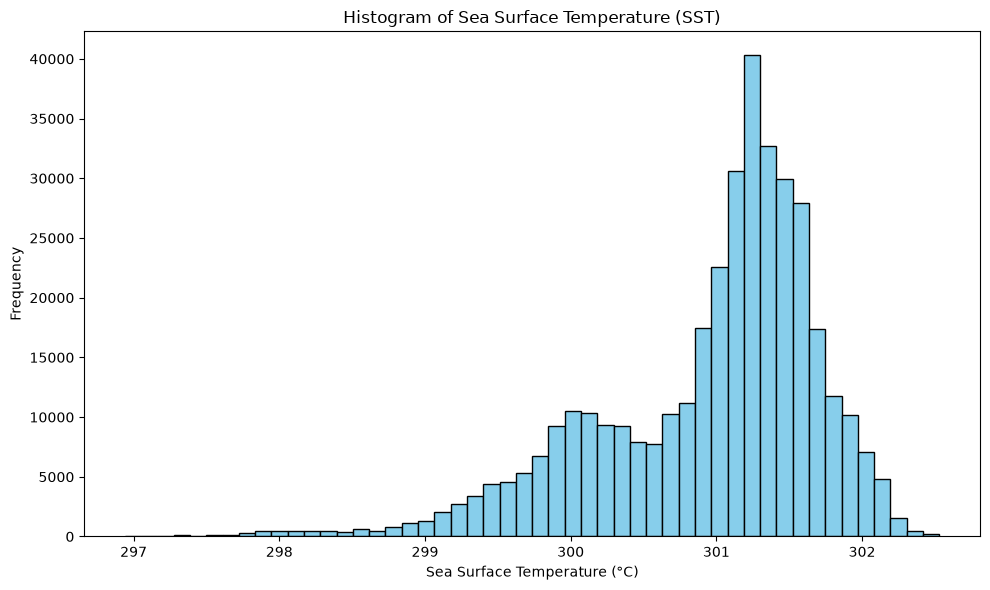

In [325]:
##SST

sst_sample = sst["sea_surface_temperature"].sel(
    time=sample_dates,
    method="nearest"
)


sst_values= sst_sample.values
sst_values=sst_values[np.isfinite(sst_values)] #filtering out invalid values

plt.figure(figsize=(10,6))

plt.hist(sst_values, bins=50, color='skyblue', edgecolor='black')

plt.xlabel("Sea Surface Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Histogram of Sea Surface Temperature (SST)")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "sst_distribution_raw.png",dpi=150,bbox_inches='tight')  

plt.show()

SST
* No obvious pathological values are visible.
* The distribution is not symmetric; it has a noticeable cooler tail.
* The raw values are in Kelvin, so the later preprocessing step will convert them to °C.
* The distribution itself does not justify removing extreme values.
* The major issue with SST remains its high missingness, which we need to investigate spatially.

Conclusion: 🟢 Values look reasonable; investigate missing-data pattern.

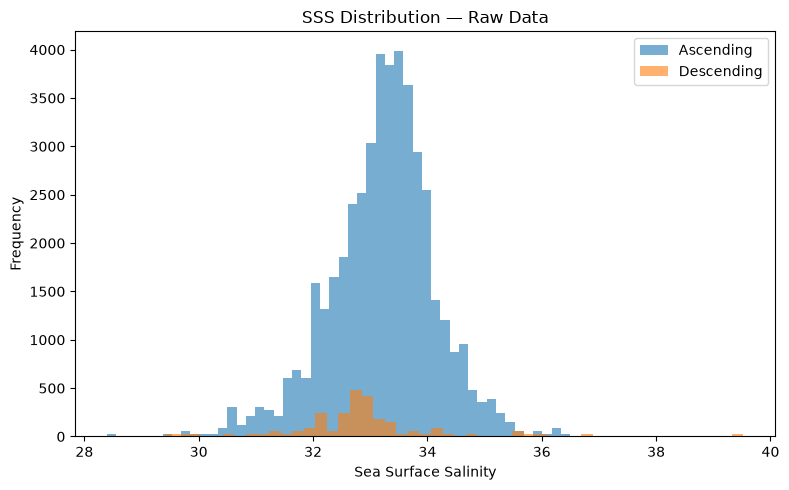

In [326]:
sss_asc_sample = sss_asc["Sea_Surface_Salinity"].sel(
    time=sample_dates,
    method="nearest"
)

sss_desc_sample = sss_desc["Sea_Surface_Salinity"].sel(
    time=sample_dates,
    method="nearest"
)

sss_asc_values = sss_asc_sample.values
sss_asc_values = sss_asc_values[np.isfinite(sss_asc_values)]

sss_desc_values = sss_desc_sample.values
sss_desc_values = sss_desc_values[np.isfinite(sss_desc_values)]

plt.figure(figsize=(8, 5))

plt.hist(sss_asc_values, bins=50, alpha=0.6, label="Ascending")
plt.hist(sss_desc_values, bins=50, alpha=0.6, label="Descending")

plt.xlabel("Sea Surface Salinity")
plt.ylabel("Frequency")
plt.title("SSS Distribution — Raw Data")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* Ascending and descending SSS do not have identical statistical behavior.
* The ascending product contains potentially suspicious high-salinity observations.
* However, the graph alone does not prove that those values are erroneous.
* We should investigate where those high values occur geographically and whether they occur in isolated pixels or coherent regions.
* The two datasets should therefore not simply be blindly averaged yet.

Conclusion: 🔴 Requires dedicated SSS QC/outlier investigation.

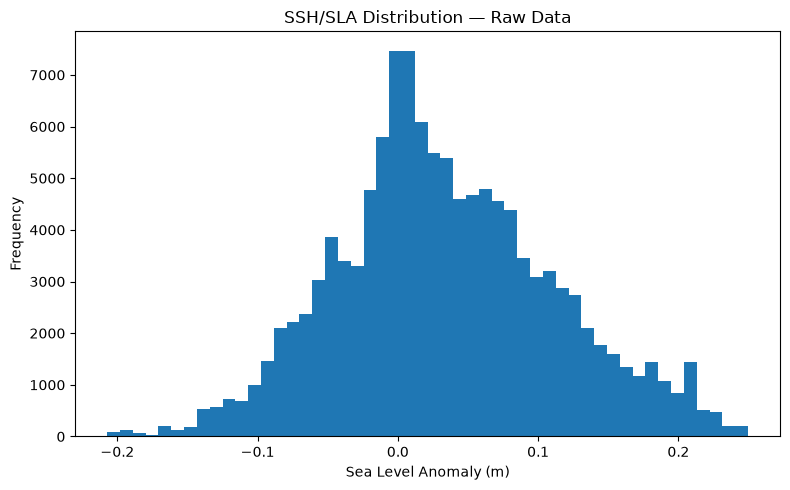

In [327]:
ssh_sample = ssh["sla"].sel(
    time=sample_dates,
    method="nearest"
)

ssh_values = ssh_sample.values
ssh_values = ssh_values[np.isfinite(ssh_values)]

plt.figure(figsize=(8, 5))

plt.hist(ssh_values, bins=50)

plt.xlabel("Sea Level Anomaly (m)")
plt.ylabel("Frequency")
plt.title("SSH/SLA Distribution — Raw Data")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ssh_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* The distribution is broadly centered around zero.
* Positive and negative anomalies are expected for SLA.
* No obvious pathological spike or impossible-looking distribution is visible.
* The slight positive skew is not itself a problem.

Conclusion: 🟢 No immediate anomaly; retain for further spatial/QC analysis.

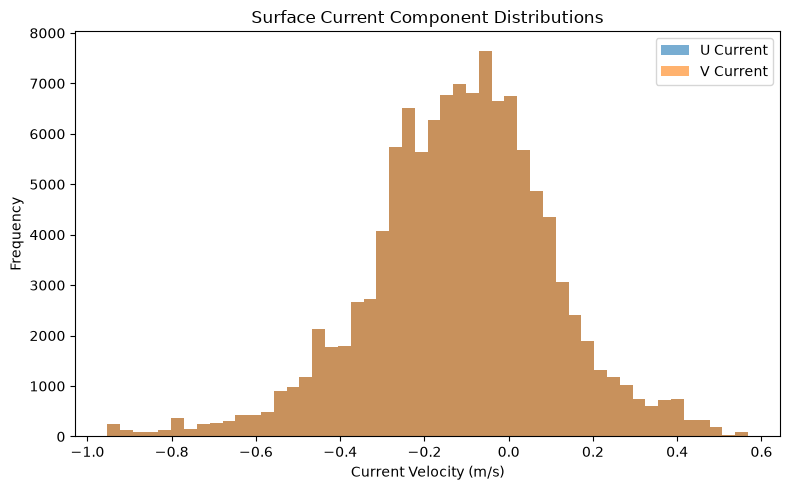

In [328]:
uo_sample = currents["uo"].sel(
    time=sample_dates,
    method="nearest"
)

vo_sample = currents["vo"].sel(
    time=sample_dates,
    method="nearest"
)

uo_values = uo_sample.values
uo_values = uo_values[np.isfinite(uo_values)]

vo_values = uo_sample.values
vo_values = vo_values[np.isfinite(vo_values)]

plt.figure(figsize=(8, 5))

plt.hist(uo_values, bins=50, alpha=0.6, label="U Current")
plt.hist(vo_values, bins=50, alpha=0.6, label="V Current")

plt.xlabel("Current Velocity (m/s)")
plt.ylabel("Frequency")
plt.title("Surface Current Component Distributions")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* The distributions look continuous rather than containing obvious isolated numerical spikes.
* The tails should nevertheless be checked spatially.
* We should not remove negative values.
* We should eventually consider current speed as an additional diagnostic:
$$ Speed = \sqrt{U^2 + V^2} $$

* but we don't necessarily need to make speed a model input because our planned input channels remain U/V.

Conclusion: 🟢 No obvious anomaly; perform physical/extreme-value QC later.

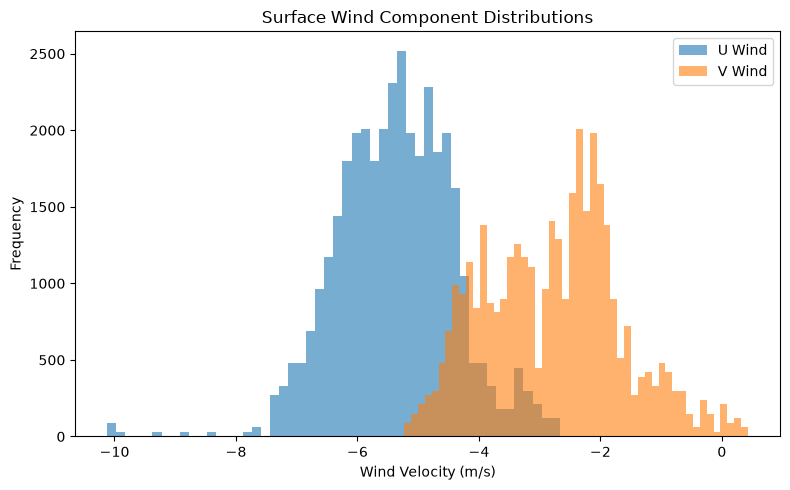

In [329]:
wind_u_sample = winds["eastward_wind"].sel(
    time=sample_dates,
    method="nearest"
)

wind_v_sample = winds["northward_wind"].sel(
    time=sample_dates,
    method="nearest"
)


wind_u_values = wind_u_sample.values
wind_u_values = wind_u_values[np.isfinite(wind_u_values)]

wind_v_values = wind_v_sample.values
wind_v_values = wind_v_values[np.isfinite(wind_v_values)]

plt.figure(figsize=(8, 5))

plt.hist(wind_u_values, bins=50, alpha=0.6, label="U Wind")
plt.hist(wind_v_values, bins=50, alpha=0.6, label="V Wind")

plt.xlabel("Wind Velocity (m/s)")
plt.ylabel("Frequency")
plt.title("Surface Wind Component Distributions")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* Values themselves don't immediately look like impossible numerical values.
* The strong asymmetry is worth investigating.
* The much bigger concern is the 72.4% missingness.
* The spatial pattern of the available observations is therefore critical.
* We should investigate whether the missing values follow the ASCAT swath pattern.

Conclusion: 🟡 Values require some investigation, but missingness/swath coverage is the bigger issue.

### Distribution EDA — Initial Inference

The raw-variable distributions provide several important observations.

1. SST shows a broad but physically plausible distribution. No obvious
   pathological values are evident, although its high missing-data
   fraction requires spatial investigation.

2. SSS shows substantially different distributions between ascending
   and descending observations. The ascending product has a broader
   distribution and a pronounced high-salinity tail reaching ~40–41.
   These values should not be removed automatically and require
   spatial and overlap-based QC.

3. SSH/SLA is approximately centered around zero with a reasonable
   spread and no obvious pathological distribution.

4. Surface current components show directional asymmetry, particularly
   for the U component. Negative values represent physical direction
   and should not be treated as invalid values. Extreme velocities
   require further spatial/physical investigation.

5. Surface wind components show strong asymmetry, particularly in the
   U component. The values do not immediately indicate invalid data,
   but the high missing-data fraction and observation/swath pattern
   require further investigation.

6. GLORYS temperature should be analyzed separately by depth because
   combining all depths into one distribution masks the vertical
   temperature structure.

Overall, no variable should be cleaned solely on the basis of these
histograms. The next stage is targeted outlier and spatial analysis,
particularly for SSS and the high-missingness surface observations.

## 2B. SSS Ascending/Descending Outlier Investigation

The distribution analysis showed that the ascending SSS product has a
broader distribution and a high-value tail reaching approximately
40–41, while the descending product is more concentrated.

Before applying any QC rule, we investigate:

1. SSS metadata and units
2. Distribution quantiles
3. Number of extreme observations
4. Spatial location of extreme observations
5. Agreement between ascending and descending observations
6. Whether extreme values occur in coherent regions or isolated pixels

No observations are removed during this analysis.

In [187]:
print("SSS Ascending attributes:")
print(sss_asc["Sea_Surface_Salinity"].attrs)

print("\nSSS Descending attributes:")
print(sss_desc["Sea_Surface_Salinity"].attrs)

SSS Ascending attributes:
{'ancillary_variables': 'Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC', 'long_name': 'Practical sea surface salinity', 'regrid_method': 'bilinear', 'standard_name': 'sea_surface_salinity', 'units': '0.001', 'valid_max': np.float32(12000.0), 'valid_min': np.float32(-30000.0)}

SSS Descending attributes:
{'ancillary_variables': 'Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC', 'long_name': 'Practical sea surface salinity', 'regrid_method': 'bilinear', 'standard_name': 'sea_surface_salinity', 'units': '0.001', 'valid_max': np.float32(12000.0), 'valid_min': np.float32(-30000.0)}


### SSS Metadata Interpretation

Both SSS ascending and descending datasets represent practical
sea surface salinity.

The variable metadata references associated error and QC variables,
but the current downloaded subset contains only the primary
Sea_Surface_Salinity variable.

Therefore, this investigation uses the available salinity field,
metadata-defined validity information, distributional analysis,
spatial structure, and ascending/descending comparison.

The broad metadata limits are not used as direct physical
outlier thresholds.

In [330]:
sss_asc_da = sss_asc["Sea_Surface_Salinity"]
sss_desc_da = sss_desc["Sea_Surface_Salinity"]

quantile_levels = [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]

asc_quantiles = (
    sss_asc_da
    .where(np.isfinite(sss_asc_da))
    .quantile(quantile_levels)
    .compute()
)

desc_quantiles = (
    sss_desc_da
    .where(np.isfinite(sss_desc_da))
    .quantile(quantile_levels)
    .compute()
)

print("SSS Ascending quantiles")
print("-" * 35)

for q, value in zip(quantile_levels, asc_quantiles.values):
    print(f"{q * 100:5.1f}% : {value:.3f}")

print("\nSSS Descending quantiles")
print("-" * 35)

for q, value in zip(quantile_levels, desc_quantiles.values):
    print(f"{q * 100:5.1f}% : {value:.3f}")

SSS Ascending quantiles
-----------------------------------
 90.0% : 33.983
 95.0% : 34.380
 97.5% : 34.768
 99.0% : 35.282
 99.5% : 35.808
 99.9% : 37.195

SSS Descending quantiles
-----------------------------------
 90.0% : 34.035
 95.0% : 34.434
 97.5% : 34.827
 99.0% : 35.466
 99.5% : 36.058
 99.9% : 37.926


In [331]:
thresholds = [35, 36, 38, 40]

print("SSS Ascending extreme-value counts")
print("-" * 45)

asc_valid_count = sss_asc_da.count().compute().item()

for threshold in thresholds:
    count = (
        sss_asc_da
        .where(sss_asc_da > threshold)
        .count()
        .compute()
        .item()
    )

    percentage = count / asc_valid_count * 100

    print(
        f"> {threshold:2d}: "
        f"{count:8d} observations "
        f"({percentage:.3f}%)"
    )


print("\nSSS Descending extreme-value counts")
print("-" * 45)

desc_valid_count = sss_desc_da.count().compute().item()

for threshold in thresholds:
    count = (
        sss_desc_da
        .where(sss_desc_da > threshold)
        .count()
        .compute()
        .item()
    )

    percentage = count / desc_valid_count * 100

    print(
        f"> {threshold:2d}: "
        f"{count:8d} observations "
        f"({percentage:.3f}%)"
    )

SSS Ascending extreme-value counts
---------------------------------------------
> 35:      347 observations (1.631%)
> 36:       88 observations (0.414%)
> 38:        7 observations (0.033%)
> 40:        1 observations (0.005%)

SSS Descending extreme-value counts
---------------------------------------------
> 35:      811 observations (1.896%)
> 36:      229 observations (0.535%)
> 38:       42 observations (0.098%)
> 40:        5 observations (0.012%)


In [338]:
asc = sss_asc_da
desc = sss_desc_da

overlap = (
    asc.notnull()
    & desc.notnull()
)

overlap_count = overlap.sum().compute().item()
asc_valid_count = asc.notnull().sum().compute().item()
desc_valid_count = desc.notnull().sum().compute().item()

print("SSS Ascending/Descending overlap")
print("-" * 40)
print("Overlap observations:", overlap_count)
print("Ascending valid observations:", asc_valid_count)
print("Descending valid observations:", desc_valid_count)

SSS Ascending/Descending overlap
----------------------------------------
Overlap observations: 2385
Ascending valid observations: 21275
Descending valid observations: 42775


In [339]:
overlap_from_asc = (
    overlap.sum() / asc.notnull().sum()
).compute().item() * 100

overlap_from_desc = (
    overlap.sum() / desc.notnull().sum()
).compute().item() * 100

print(f"Overlap relative to ascending valid data: {overlap_from_asc:.3f}%")
print(f"Overlap relative to descending valid data: {overlap_from_desc:.3f}%")

Overlap relative to ascending valid data: 11.210%
Overlap relative to descending valid data: 5.576%


In [343]:
high_asc = asc > 35

high_asc_overlap = high_asc & overlap

high_asc_count = high_asc.sum().compute().item()
high_asc_with_desc = high_asc_overlap.sum().compute().item()

print("High ascending SSS observations")
print("-" * 45)
print("Ascending SSS > 35:", high_asc_count)
print(
    "SSS > 35 with descending counterpart:",
    high_asc_with_desc
)

if high_asc_count > 0:
    print(
        "Percentage with descending counterpart:",
        f"{high_asc_with_desc / high_asc_count * 100:.3f}%"
    )

High ascending SSS observations
---------------------------------------------
Ascending SSS > 35: 347
SSS > 35 with descending counterpart: 55
Percentage with descending counterpart: 15.850%


In [344]:
sss_asc_high = (
    sss_asc_da > 35
)

monthly_high_count = (
    sss_asc_high
    .resample(time="1MS")
    .sum()
    .compute()
)

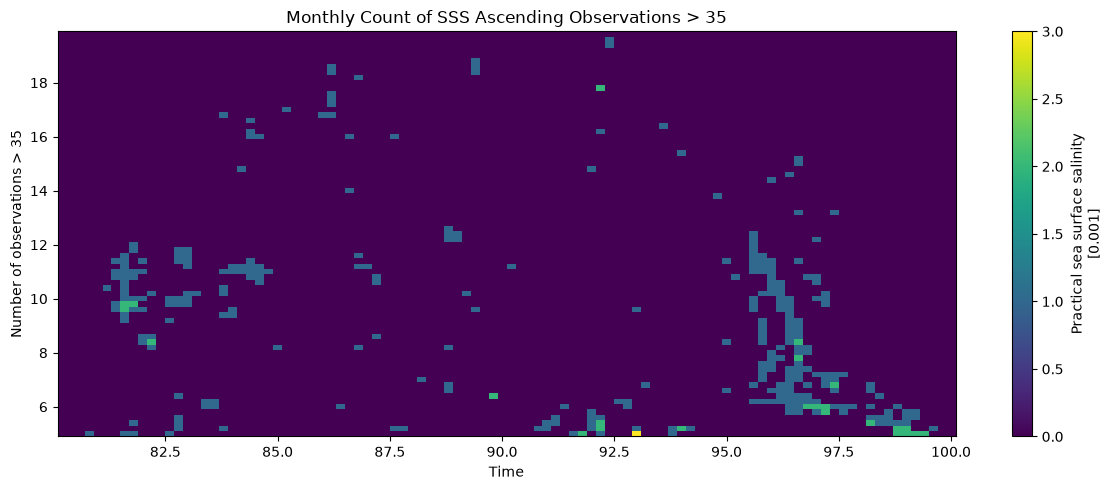

In [345]:
plt.figure(figsize=(12, 5))

monthly_high_count.plot()

plt.xlabel("Time")
plt.ylabel("Number of observations > 35")
plt.title("Monthly Count of SSS Ascending Observations > 35")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_extreme_temporal.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [346]:
monthly_valid = (
    sss_asc_da
    .notnull()
    .resample(time="1MS")
    .sum()
)

monthly_extreme = (
    (sss_asc_da > 35)
    .resample(time="1MS")
    .sum()
)

monthly_extreme_percentage = (
    monthly_extreme / monthly_valid * 100
).compute()

/Volumes/SAM-T7/SIH/Antarbodh-demo/.venv/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


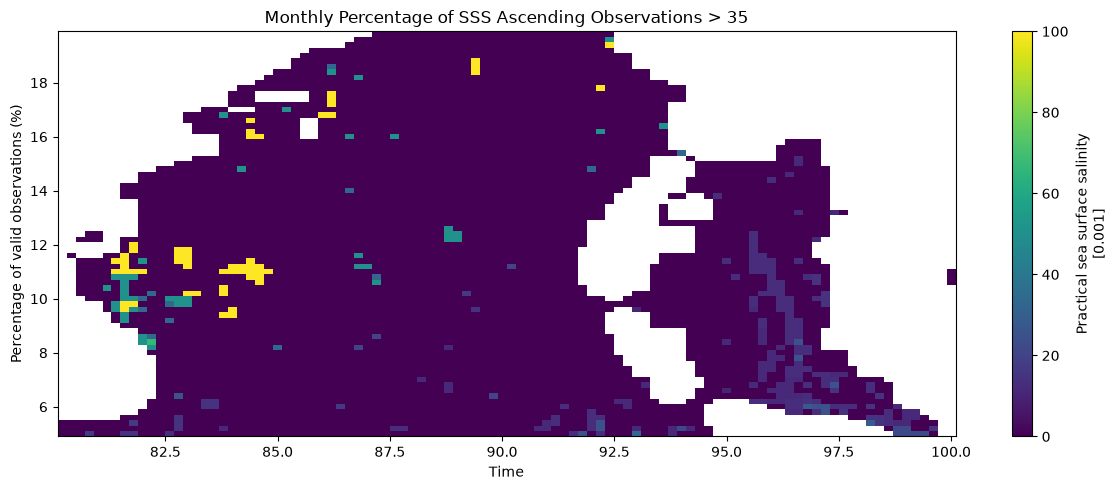

In [347]:
plt.figure(figsize=(12, 5))

monthly_extreme_percentage.plot()

plt.xlabel("Time")
plt.ylabel("Percentage of valid observations (%)")
plt.title("Monthly Percentage of SSS Ascending Observations > 35")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_extreme_percentage_temporal.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [348]:
sss_asc_extreme_frequency = (
    (sss_asc_da > 35)
    .sum(dim="time")
)

sss_asc_valid_frequency = (
    sss_asc_da.notnull()
    .sum(dim="time")
)

sss_asc_extreme_percentage = (
    sss_asc_extreme_frequency
    / sss_asc_valid_frequency
    * 100
)

/Volumes/SAM-T7/SIH/Antarbodh-demo/.venv/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


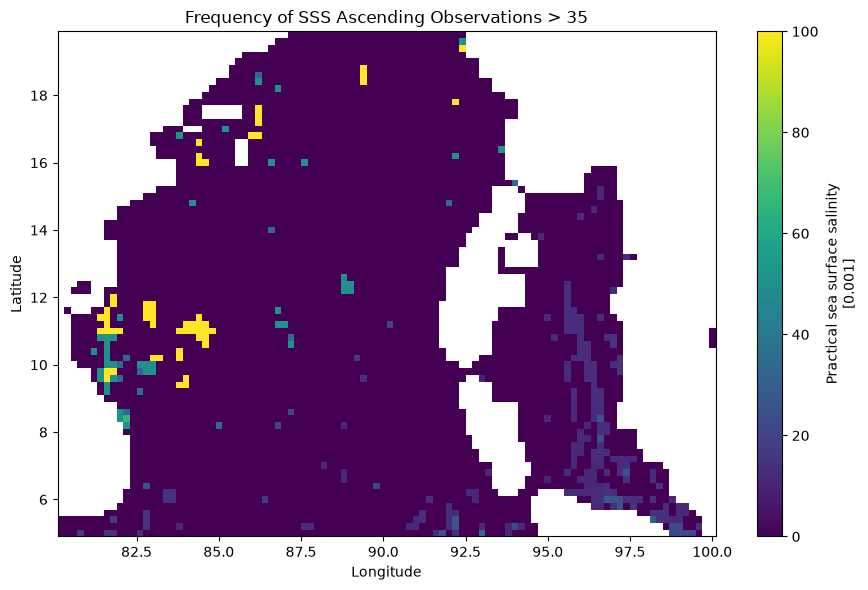

In [349]:
sss_asc_extreme_percentage.plot(
    figsize=(9, 6)
)

plt.title(
    "Frequency of SSS Ascending Observations > 35"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_extreme_frequency.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### SSS Outlier Investigation — Conclusion

The SSS ascending product exhibits a broader upper-tail distribution
than the descending product.

High-salinity observations are treated as candidate extreme
observations rather than automatically invalid measurements.

Their interpretation is based on:

- distributional quantiles
- frequency of extreme observations
- temporal persistence
- spatial coherence
- ascending/descending overlap where available

The ascending and descending products have limited simultaneous
spatial coverage, so absence of a descending counterpart does not by
itself establish that an ascending observation is invalid.

Therefore, no blanket threshold-based removal of SSS observations is
applied at this stage.

The extreme observations will remain available for downstream QC,
while observation masks preserve the distinction between observed
and missing data.

In [197]:
print("SSS Ascending variables:")
print(list(sss_asc.variables))

print("\nSSS Descending variables:")
print(list(sss_desc.variables))

SSS Ascending variables:
['Sea_Surface_Salinity', 'latitude', 'longitude', 'time']

SSS Descending variables:
['Sea_Surface_Salinity', 'latitude', 'longitude', 'time']


In [198]:
print("\nSSS Ascending data variables:")
print(list(sss_asc.data_vars))

print("\nSSS Descending data variables:")
print(list(sss_desc.data_vars))


SSS Ascending data variables:
['Sea_Surface_Salinity']

SSS Descending data variables:
['Sea_Surface_Salinity']


## 3. Spatial Exploratory Data Analysis

This section examines the spatial structure of the raw observations.

The objectives are to:

- visualize the spatial distribution of each surface variable
- identify spatially coherent features
- identify land/coastal effects
- inspect extreme-value locations
- understand the spatial pattern of missing observations
- assess whether missing values appear as isolated gaps or large unsupported regions

No interpolation, gap filling, regridding, or value modification is performed
during this stage.

In [355]:
sample_dates = [
    "2020-01-15",
    "2020-04-15",
    "2020-07-15",
    "2020-10-15",
]

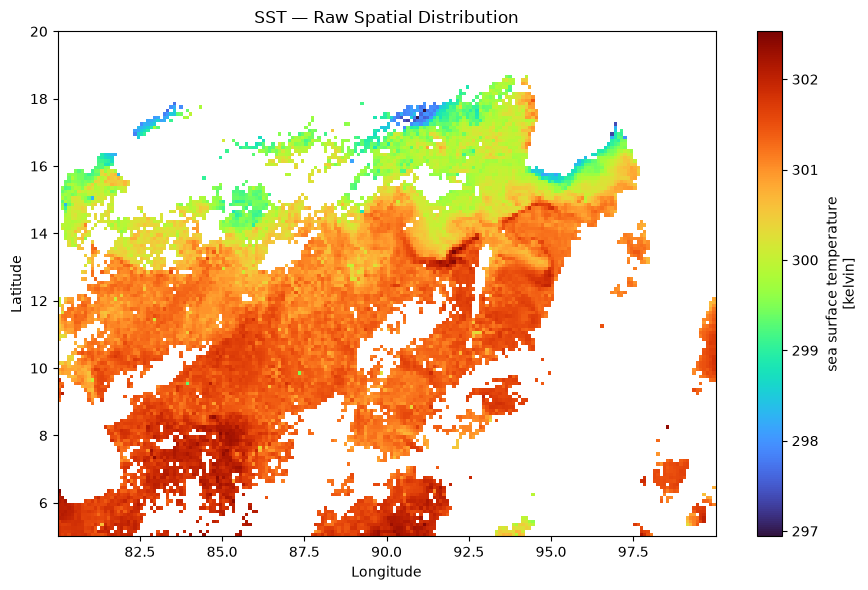

In [357]:
plt.figure(figsize=(9, 6))

sst["sea_surface_temperature"].isel(time=0).plot(
    cmap="turbo"
)

plt.title("SST — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The SST field has a very clear spatial gradient.

Broadly:

warmer temperatures dominate the southern part
cooler temperatures appear toward the north
there are localized structures and gradients
there are also gaps within the ocean coverage

The values are around 297–303 K, consistent with our earlier statistics.

Inference

The SST field is spatially coherent and physically structured.

That's good because SST is likely to be one of the strongest surface predictors for subsurface temperature.

Also notice something important:

The SST spatial structure looks broadly similar to the shallow GLORYS temperature structure.

That doesn't mean they're identical — and they shouldn't be — but the broad thermal patterns are consistent.

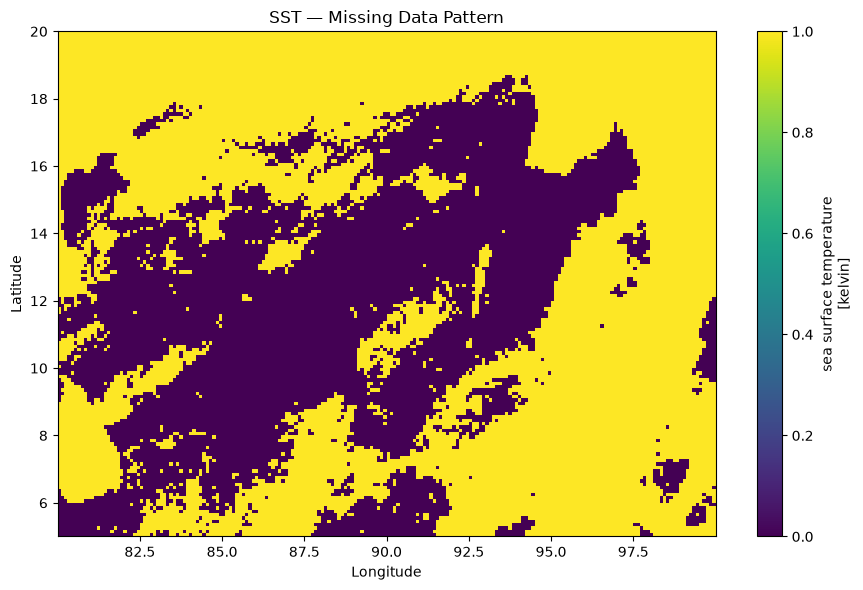

In [200]:
sst_missing = sst["sea_surface_temperature"].isel(time=0).isnull()

plt.figure(figsize=(9, 6))

sst_missing.plot()

plt.title("SST — Missing Data Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_missing_pattern.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The missing regions are not randomly scattered.

There are:

large coherent missing regions
irregular boundaries
smaller holes within observed regions
substantial areas of missing data

This explains our earlier:

58.06% missing

statistic.

Inference

The 58% number looks alarming by itself, but the map gives us the actual story:

SST missingness has strong spatial structure.

Therefore, we shouldn't say:

"SST has too many missing values, so the dataset is unusable."

Instead:

"SST has substantial but spatially structured missingness, requiring conservative gap treatment and an observation mask."

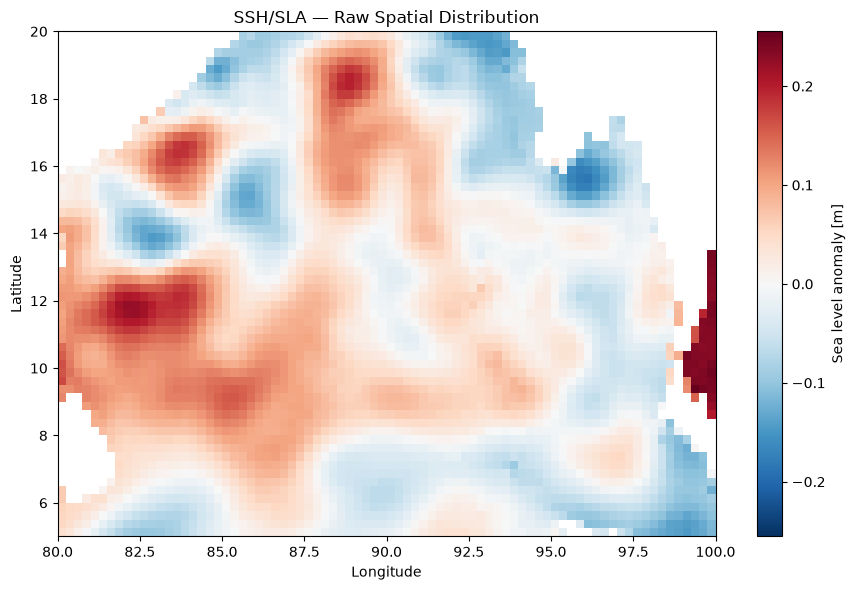

In [201]:
plt.figure(figsize=(9, 6))

ssh["sla"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("SSH/SLA — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ssh_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

SSH/SLA — raw spatial distribution

This is a very good-looking oceanographic field.

What we see

* There are alternating positive and negative sea-level anomalies across the Bay of Bengal.

For example:

* positive anomalies around parts of the western/central domain
* negative anomalies toward other regions
* localized strong positive/negative features
* relatively smooth spatial transitions

Inference

* The SSH/SLA field contains mesoscale spatial structure rather than behaving like noise.

* These structures can be associated with ocean circulation features such as eddies and large-scale dynamical variability.

For our project, this is particularly important because SSH/SLA is one of the surface variables that potentially carries information about subsurface thermal structure.

Preprocessing implication

 * Preserve positive and negative values.

 * Keep the original sign.

 * Do not convert negative SLA to zero.

 * Do not use a generic positive-only normalization.

Our normalization later should be something like standardized scaling:

$$ x' = \frac{x-\mu}{\sigma} $$

using training data statistics.

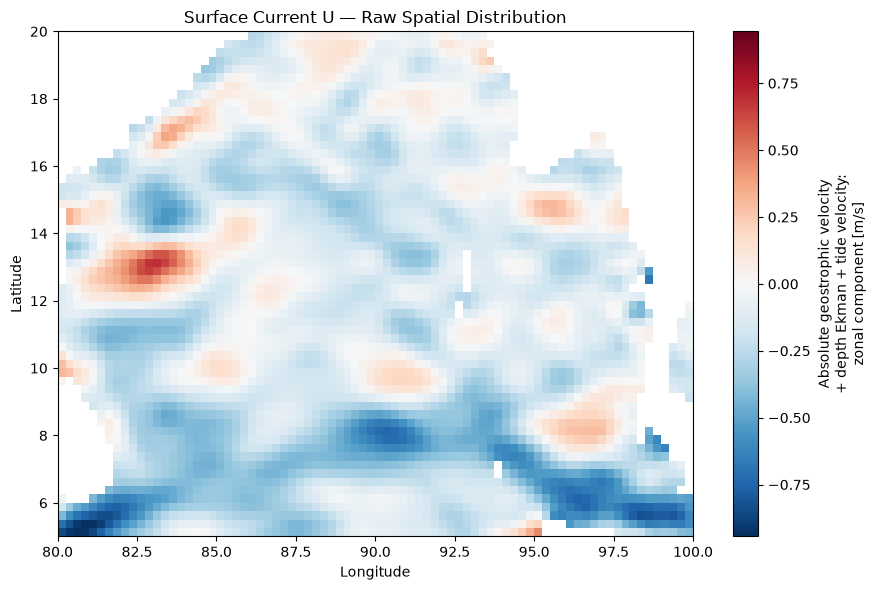

In [202]:
plt.figure(figsize=(9, 6))

currents["uo"].isel(time=0, depth=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Current U — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_u_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

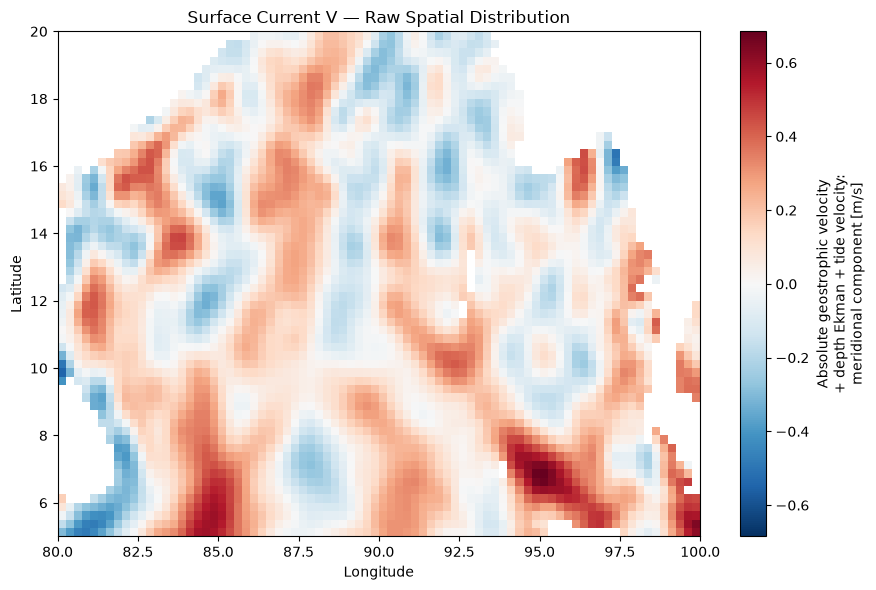

In [203]:
plt.figure(figsize=(9, 6))

currents["vo"].isel(time=0, depth=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Current V — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_v_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

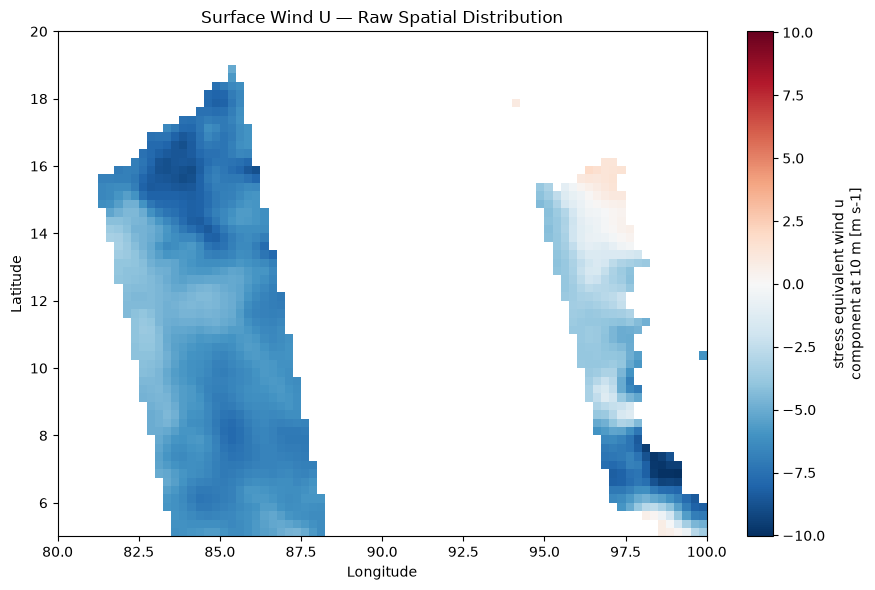

In [204]:
plt.figure(figsize=(9, 6))

winds["eastward_wind"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Wind U — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_u_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

Wind U isn't available over the entire domain.

Instead, there are two major observed spatial regions/footprints with substantial gaps between them.

The field itself is spatially structured within those footprints.

Inference

This is characteristic of the sampling/coverage pattern of the selected wind product, rather than evidence that wind velocity is zero outside the observed area.

This is crucial.

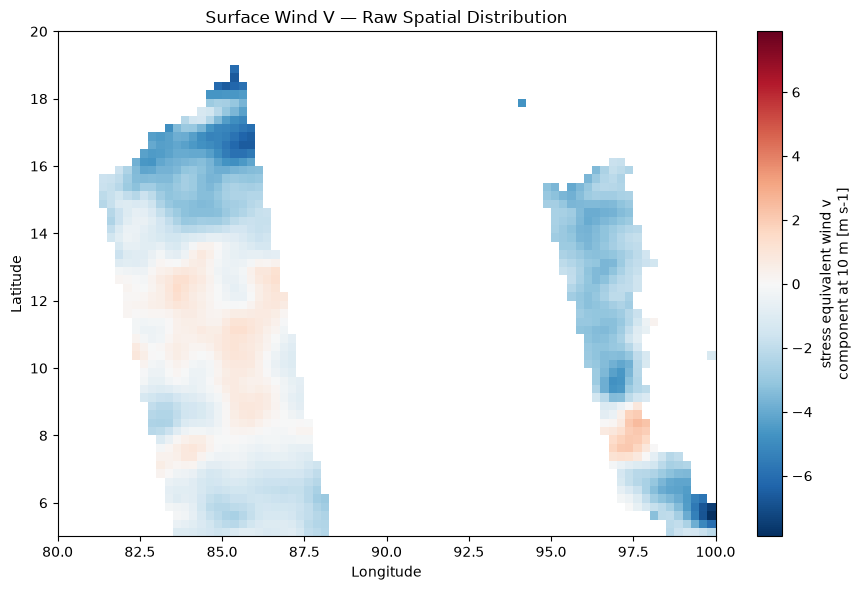

In [205]:
plt.figure(figsize=(9, 6))

winds["northward_wind"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Wind V — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_v_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

The V component shows a similar observation footprint but a different spatial pattern in the actual values.

What we see
Stronger negative values toward parts of the northern/western observed footprint.
More moderate values elsewhere.
Some positive regions exist.
The eastern/central missing regions correspond largely to lack of observations rather than zero wind.
Inference

The U and V components contain different information, which is exactly what we want.

Together:

$$ \vec{W}=(U,V) $$

describe the surface wind vector.

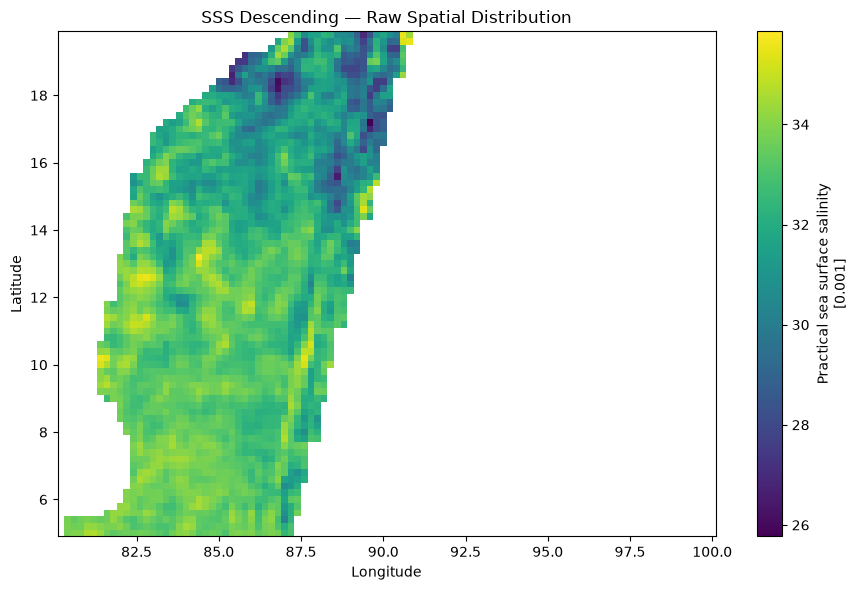

In [206]:
plt.figure(figsize=(9, 6))

sss_desc["Sea_Surface_Salinity"].isel(time=0).plot(
    cmap="viridis"
)

plt.title("SSS Descending — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_descending_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

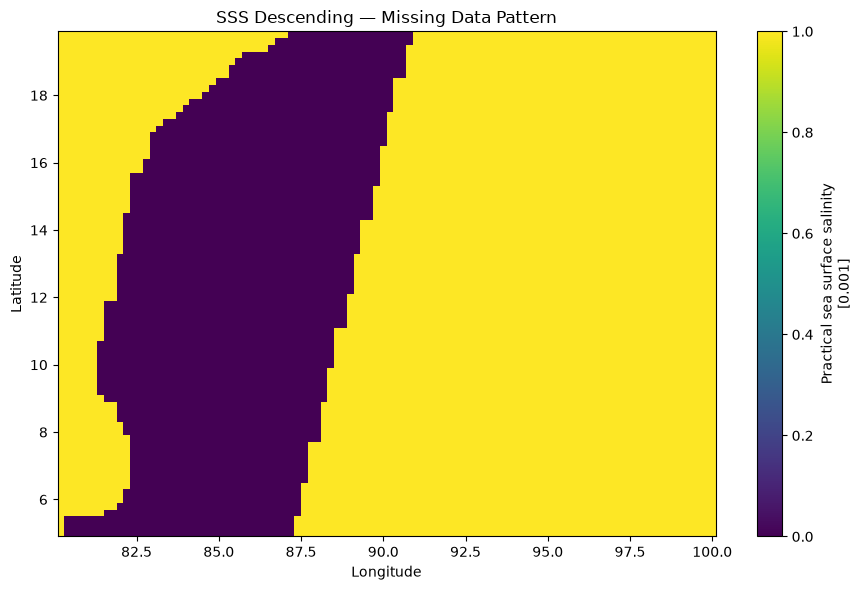

In [207]:
sss_desc_missing = (
    sss_desc["Sea_Surface_Salinity"]
    .isel(time=0)
    .isnull()
)

plt.figure(figsize=(9, 6))

sss_desc_missing.plot()

plt.title("SSS Descending — Missing Data Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_descending_missing_pattern.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The descending product has much broader coverage than the ascending product on this particular day, but it is still far from complete domain coverage.

There is a large contiguous observed region in the western/central portion of the domain, while much of the eastern side has no observations.

Inference

Again, missingness is structured, not random.

Also, ascending and descending clearly have different spatial sampling patterns.

This explains why their overlap was only about:

0.57%

for this particular sample.

This plot makes the previous point even clearer.

Remember:

yellow = missing
purple = observed

What we see

There is a very large contiguous missing region.

The observed region forms a broad spatial footprint rather than random scattered pixels.

Inference

This is observation-coverage missingness, not simply random sensor noise.

That means filling the entire yellow region using spatial interpolation would be dangerous.

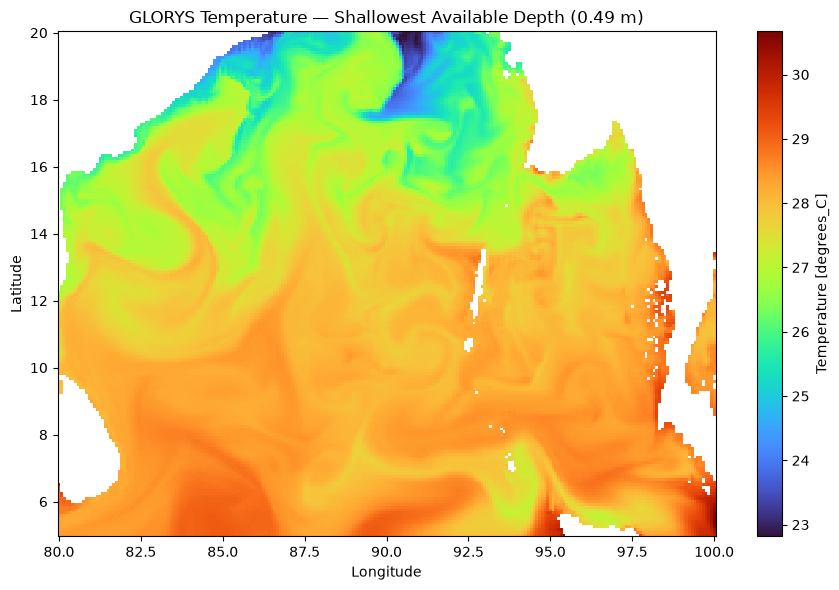

In [208]:
plt.figure(figsize=(9, 6))

glorys["thetao"].isel(time=0, depth=0).plot(
    cmap="turbo"
)

plt.title(
    f"GLORYS Temperature — Shallowest Available Depth "
    f"({glorys.depth.isel(depth=0).item():.2f} m)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_surface_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see
* Temperature is spatially structured, not random.
* The southern part of the domain is generally warmer, while the northern part is cooler.
* There are clear curved/mesoscale structures in the field.
* Temperatures are approximately 23–31°C in the plotted region.
* There are sharp gradients around some regions, especially toward the northern Bay of Bengal.
* There are also land/coastal/bathymetry-related missing regions.

Inference

This is exactly the kind of structure we expect from an ocean temperature field.

| Variable        | Main spatial observation                        | Preliminary preprocessing implication               |
| --------------- | ----------------------------------------------- | --------------------------------------------------- |
| **SST**         | Strong coherent thermal field + structured gaps | Convert K→°C; conservative interpolation + mask     |
| **SSS Asc**     | Very sparse, structured sampling                | Combine with descending; retain mask                |
| **SSS Desc**    | Broader but still incomplete coverage           | Combine with ascending; retain mask                 |
| **SSH/SLA**     | Strong positive/negative spatial structures     | Preserve sign and spatial variability               |
| **Current U/V** | Coherent velocity structures + missing regions  | Keep U/V separately; preserve masks                 |
| **Wind U/V**    | Strong sampling footprint + spatial variability | Keep U/V separately; never equate missing with zero |
| **GLORYS θ**    | Smooth/coherent thermal structures              | Preserve spatial structure; inspect depth-wise NaNs |


## 6. GLORYS Depth-wise Exploratory Data Analysis

The ANTARBODH target consists of subsurface temperature at 15 target
depths ranging from 0 m to 1000 m.

Before performing vertical interpolation, this section examines:

- temperature statistics as a function of depth
- the vertical temperature structure
- missing-data percentage at each native GLORYS depth
- the availability of data near the deepest target depth
- whether the selected 15 target depths are supported by the native GLORYS profile

No interpolation or modification of the GLORYS target is performed in
this section.

In [209]:
print("Number of native GLORYS depth levels:", glorys.sizes["depth"])

print("\nNative GLORYS depths:")
print(glorys["depth"].values)

Number of native GLORYS depth levels: 36

Native GLORYS depths:
[4.940250e-01 1.541375e+00 2.645669e+00 3.819495e+00 5.078224e+00
 6.440614e+00 7.929560e+00 9.572997e+00 1.140500e+01 1.346714e+01
 1.581007e+01 1.849556e+01 2.159882e+01 2.521141e+01 2.944473e+01
 3.443415e+01 4.034405e+01 4.737369e+01 5.576429e+01 6.580727e+01
 7.785385e+01 9.232607e+01 1.097293e+02 1.306660e+02 1.558507e+02
 1.861256e+02 2.224752e+02 2.660403e+02 3.181274e+02 3.802130e+02
 4.539377e+02 5.410889e+02 6.435668e+02 7.633331e+02 9.023393e+02
 1.062440e+03]


In [358]:
# ============================================================
# GLORYS — Depth-wise Statistics
# ============================================================

thetao = glorys["thetao"]

depth_dims = [
    "time",
    "latitude",
    "longitude"
]

depth_valid_count = (
    thetao.notnull()
    .sum(dim=depth_dims)
)

depth_missing_fraction = (
    thetao.isnull()
    .mean(dim=depth_dims)
)

depth_min = (
    thetao.min(
        dim=depth_dims,
        skipna=True
    )
)

depth_mean = (
    thetao.mean(
        dim=depth_dims,
        skipna=True
    )
)

depth_max = (
    thetao.max(
        dim=depth_dims,
        skipna=True
    )
)

depth_std = (
    thetao.std(
        dim=depth_dims,
        skipna=True
    )
)

glorys_depth_stats = xr.Dataset(
    {
        "valid_count": depth_valid_count,
        "missing_fraction": depth_missing_fraction,
        "min": depth_min,
        "mean": depth_mean,
        "max": depth_max,
        "std": depth_std,
    }
)

# Execute the complete calculation together
glorys_depth_stats = glorys_depth_stats.compute()

glorys_depth_stats

<xarray.Dataset> Size: 2kB
Dimensions:           (depth: 36)
Coordinates:
  * depth             (depth) float32 144B 0.494 1.541 2.646 ... 902.3 1.062e+03
Data variables:
    valid_count       (depth) int64 288B 35400 35400 35400 ... 28180 27797 27311
    missing_fraction  (depth) float64 288B 0.1885 0.1885 ... 0.3628 0.3739
    min               (depth) float64 288B 22.82 22.81 22.8 ... 6.253 5.638
    mean              (depth) float64 288B 27.67 27.67 27.66 ... 7.266 6.313
    max               (depth) float64 288B 30.67 30.65 30.62 ... 8.207 7.394
    std               (depth) float64 288B 0.9653 0.9639 ... 0.2577 0.2413

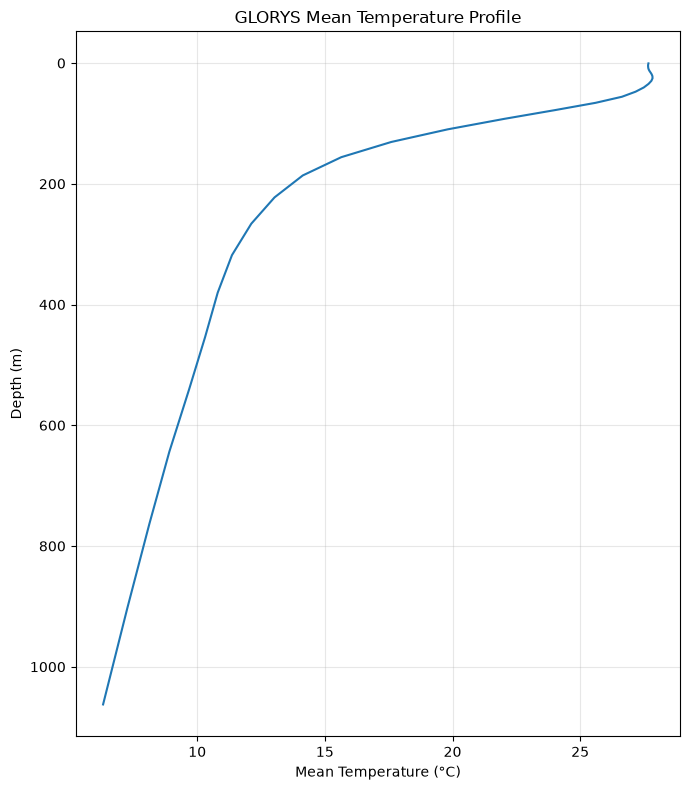

In [359]:
# ============================================================
# GLORYS — Mean Temperature Profile
# ============================================================

mean_profile = (
    thetao
    .mean(
        dim=[
            "time",
            "latitude",
            "longitude"
        ],
        skipna=True
    )
    .compute()
)

plt.figure(figsize=(7, 8))

plt.plot(
    mean_profile.values,
    glorys["depth"].values
)

plt.gca().invert_yaxis()

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title(
    "GLORYS Mean Temperature Profile"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_mean_temperature_profile.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

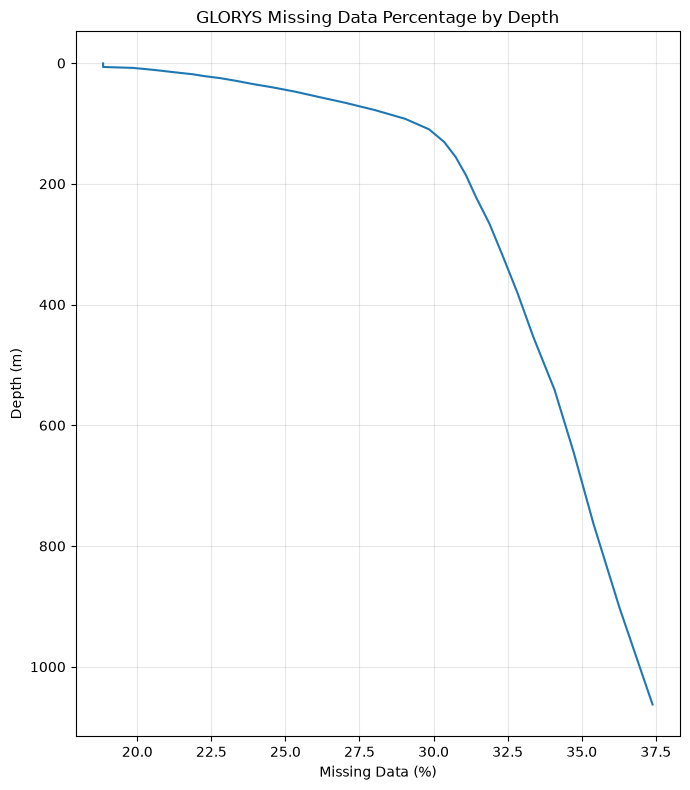

In [360]:
# ============================================================
# GLORYS — Missing Data Percentage by Depth
# ============================================================

missing_by_depth = (
    thetao
    .isnull()
    .mean(
        dim=[
            "time",
            "latitude",
            "longitude"
        ]
    )
    * 100
)

missing_by_depth = missing_by_depth.compute()

plt.figure(figsize=(7, 8))

plt.plot(
    missing_by_depth.values,
    glorys["depth"].values
)

plt.gca().invert_yaxis()

plt.xlabel("Missing Data (%)")
plt.ylabel("Depth (m)")
plt.title(
    "GLORYS Missing Data Percentage by Depth"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_missingness_by_depth.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [361]:
# ============================================================
# ANTARBODH Target Depths
# ============================================================

target_depths = np.array([
    0,
    5,
    10,
    20,
    30,
    50,
    75,
    100,
    125,
    150,
    200,
    300,
    500,
    700,
    1000
])

print(
    "ANTARBODH target depths (m):"
)

print(target_depths)

ANTARBODH target depths (m):
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


In [362]:
# ============================================================
# GLORYS — Target Depth Support Check
# ============================================================

native_depths = glorys["depth"].values

print(
    "ANTARBODH Target Depth → "
    "Nearest Native GLORYS Level"
)

print("=" * 70)

for target_depth in target_depths:

    nearest_index = np.abs(
        native_depths - target_depth
    ).argmin()

    nearest_depth = float(
        native_depths[nearest_index]
    )

    difference = abs(
        nearest_depth - target_depth
    )

    print(
        f"{target_depth:>5.0f} m → "
        f"{nearest_depth:>9.3f} m "
        f"(difference = {difference:.3f} m)"
    )

ANTARBODH Target Depth → Nearest Native GLORYS Level
    0 m →     0.494 m (difference = 0.494 m)
    5 m →     5.078 m (difference = 0.078 m)
   10 m →     9.573 m (difference = 0.427 m)
   20 m →    18.496 m (difference = 1.504 m)
   30 m →    29.445 m (difference = 0.555 m)
   50 m →    47.374 m (difference = 2.626 m)
   75 m →    77.854 m (difference = 2.854 m)
  100 m →    92.326 m (difference = 7.674 m)
  125 m →   130.666 m (difference = 5.666 m)
  150 m →   155.851 m (difference = 5.851 m)
  200 m →   186.126 m (difference = 13.874 m)
  300 m →   318.127 m (difference = 18.127 m)
  500 m →   541.089 m (difference = 41.089 m)
  700 m →   643.567 m (difference = 56.433 m)
 1000 m →  1062.440 m (difference = 62.440 m)


In [363]:
# ============================================================
# GLORYS — 1000 m Vertical Support Check
# ============================================================

target_depth = 1000.0

shallower_depths = native_depths[
    native_depths <= target_depth
]

deeper_depths = native_depths[
    native_depths >= target_depth
]

print(
    "1000 m target support"
)

print("=" * 50)

if (
    len(shallower_depths) > 0
    and len(deeper_depths) > 0
):

    lower = float(
        shallower_depths.max()
    )

    upper = float(
        deeper_depths.min()
    )

    print(
        f"Shallower native level : "
        f"{lower:.3f} m"
    )

    print(
        f"Deeper native level    : "
        f"{upper:.3f} m"
    )

    print(
        "Result: 1000 m is bracketed "
        "and can be vertically interpolated."
    )

else:

    print(
        "Result: 1000 m is outside "
        "the native GLORYS depth range."
    )

1000 m target support
Shallower native level : 902.339 m
Deeper native level    : 1062.440 m
Result: 1000 m is bracketed and can be vertically interpolated.


In [364]:
# ============================================================
# GLORYS — 0 m Target Support Check
# ============================================================

native_surface_depth = float(
    native_depths[0]
)

print(
    f"Shallowest native GLORYS level: "
    f"{native_surface_depth:.3f} m"
)

if native_surface_depth > 0:

    print(
        "\n0 m is above the shallowest native level."
    )

    print(
        "Use the shallowest native level as the "
        "0 m proxy rather than blind extrapolation."
    )

else:

    print(
        "\nA native 0 m level is available."
    )

Shallowest native GLORYS level: 0.494 m

0 m is above the shallowest native level.
Use the shallowest native level as the 0 m proxy rather than blind extrapolation.


In [365]:
# ============================================================
# GLORYS — Availability at ANTARBODH Target Depths
# ============================================================

target_availability = []

for target_depth in target_depths:

    field = thetao.sel(
        depth=target_depth,
        method="nearest"
    )

    valid_fraction = (
        field
        .notnull()
        .mean()
        .compute()
        .item()
        * 100
    )

    native_depth = float(
        field["depth"]
        .compute()
        .item()
    )

    target_availability.append(
        {
            "target_depth_m": target_depth,
            "nearest_native_depth_m": native_depth,
            "valid_fraction_percent": valid_fraction,
        }
    )

target_availability

[{'target_depth_m': np.int64(0),
  'nearest_native_depth_m': 0.49402499198913574,
  'valid_fraction_percent': 81.15357282043053},
 {'target_depth_m': np.int64(5),
  'nearest_native_depth_m': 5.078224182128906,
  'valid_fraction_percent': 81.15357282043053},
 {'target_depth_m': np.int64(10),
  'nearest_native_depth_m': 9.572997093200684,
  'valid_fraction_percent': 79.79642832580637},
 {'target_depth_m': np.int64(20),
  'nearest_native_depth_m': 18.495559692382812,
  'valid_fraction_percent': 78.12979986703652},
 {'target_depth_m': np.int64(30),
  'nearest_native_depth_m': 29.444730758666992,
  'valid_fraction_percent': 76.66032415579652},
 {'target_depth_m': np.int64(50),
  'nearest_native_depth_m': 47.37369155883789,
  'valid_fraction_percent': 74.66816441622154},
 {'target_depth_m': np.int64(75),
  'nearest_native_depth_m': 77.85385131835938,
  'valid_fraction_percent': 71.9790926388666},
 {'target_depth_m': np.int64(100),
  'nearest_native_depth_m': 92.3260726928711,
  'valid_fracti

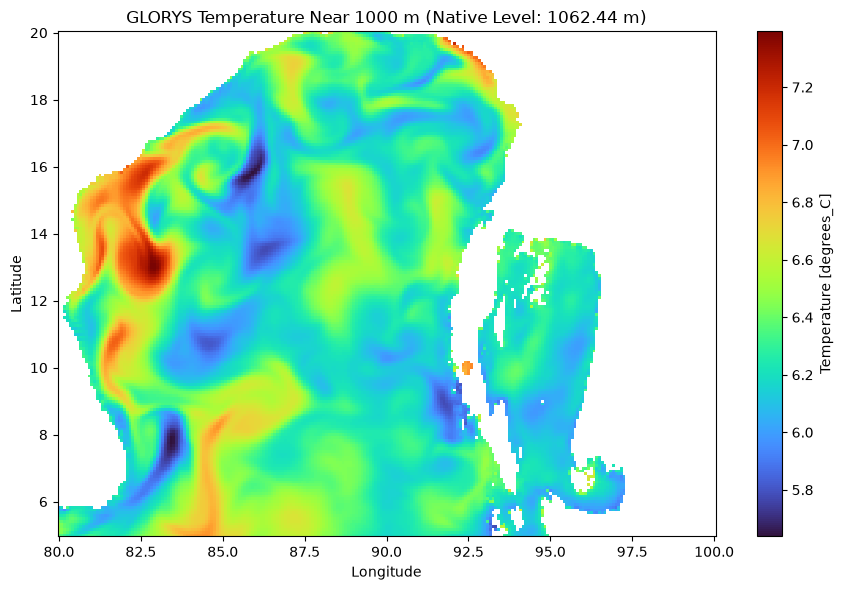

In [366]:
# ============================================================
# GLORYS — Temperature Near 1000 m
# Representative Date
# ============================================================

glorys_1000m = thetao.sel(
    depth=1000,
    method="nearest"
)

nearest_depth_1000m = float(
    glorys_1000m["depth"]
    .compute()
    .item()
)

field_1000m = glorys_1000m.sel(
    time="2020-01-15",
    method="nearest"
)

plt.figure(figsize=(9, 6))

field_1000m.plot.pcolormesh(
    cmap="turbo"
)

plt.title(
    f"GLORYS Temperature Near 1000 m "
    f"(Native Level: {nearest_depth_1000m:.2f} m)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_1000m_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### GLORYS Depth-wise EDA — Findings

The GLORYS temperature field exhibits a clear vertical thermal
structure across the analysis period.

Temperature and its variability change systematically with depth,
providing the reference subsurface structure used to train ANTARBODH.

Target-depth availability varies with depth, with deeper levels
generally having lower spatial coverage than shallow levels.

All ANTARBODH target depths are within or sufficiently supported by
the native GLORYS vertical range for the intended reconstruction.

The 1000 m target is bracketed by native GLORYS levels and can
therefore be obtained through vertical interpolation.

The 0 m target requires special handling because the shallowest native
GLORYS level is approximately 0.49 m. The shallowest native level will
be used as a proxy rather than applying blind vertical extrapolation.

The target-depth support checks in this section are diagnostic only.
Final target fields will be generated during the preprocessing stage
using the defined vertical interpolation strategy.

### Preprocessing implications

- retain the full native GLORYS depth structure during preprocessing
- vertically interpolate to the 15 ANTARBODH target depths
- use the shallowest native level as the 0 m proxy
- do not extrapolate beyond the supported GLORYS depth range
- preserve target masks
- do not globally fill missing target temperatures
- verify target-depth coverage after interpolation

## 7. Multi-variable Relationship EDA

The objective of this section is to investigate relationships between
surface observations and subsurface GLORYS temperature.

The analysis examines:

- SST vs subsurface temperature
- SSS vs subsurface temperature
- SSH/SLA vs subsurface temperature
- surface current U/V vs subsurface temperature
- surface wind U/V vs subsurface temperature
- relationships at multiple subsurface depths

This section is exploratory.

The correlation analysis is used to understand whether individual
surface variables exhibit linear spatial relationships with subsurface
temperature.

It is not used as a measure of model performance.

Because the source datasets have different native spatial resolutions
and observation footprints, the initial analysis is performed as a
representative one-day spatial diagnostic.

A full-period relationship analysis will be performed after temporal
and spatial harmonization to the common 0.25° grid.

## 7.1 Why Cross-Variable Relationship Analysis?

ANTARBODH is based on the hypothesis that surface ocean observations
contain information about the subsurface thermal structure.

Before training a machine-learning model, it is useful to investigate
whether measurable statistical relationships exist between the surface
inputs and subsurface temperature.

For example:

Surface SST
     ↓
may contain information about
     ↓
temperature at 50 m, 100 m, 200 m, etc.

However, SST alone is not expected to completely describe the subsurface
ocean.

Other variables such as salinity, sea-level anomaly, currents, and winds
may provide additional information.

Therefore, this section evaluates both individual relationships and
the combined set of surface observables.

Correlation is used as an exploratory measure, not as proof of causality.
A low correlation between an individual surface variable and a deep
temperature field does not imply that the variable is useless for a
nonlinear machine-learning model.

In [369]:
# ============================================================
# Convert SST from Kelvin to Celsius
# ============================================================

sst_c = (
    sst["sea_surface_temperature"]
    - 273.15
)

sst_c.attrs = (
    sst["sea_surface_temperature"]
    .attrs.copy()
)

sst_c.attrs["units"] = "degrees_Celsius"

print("Type:", type(sst_c))
print("Dimensions:", sst_c.dims)
print("Units:", sst_c.attrs["units"])

print(
    "SST range:",
    float(sst_c.min().compute().item()),
    "to",
    float(sst_c.max().compute().item()),
    "°C"
)

Type: <class 'xarray.core.dataarray.DataArray'>
Dimensions: ('time', 'latitude', 'longitude')
Units: degrees_Celsius
SST range: 23.79000000000002 to 29.379999999999995 °C


In [371]:
# Extract SST variable and convert Kelvin → Celsius


sst_c.attrs = sst["sea_surface_temperature"].attrs.copy()
sst_c.attrs["units"] = "degrees_Celsius"

print("Type:", type(sst_c))
print("Dimensions:", sst_c.dims)
print("Units:", sst_c.attrs["units"])
print(
    "SST range:",
    float(sst_c.min().compute().item()),
    "to",
    float(sst_c.max().compute().item()),
    "°C"
)

Type: <class 'xarray.core.dataarray.DataArray'>
Dimensions: ('time', 'latitude', 'longitude')
Units: degrees_Celsius
SST range: 23.79000000000002 to 29.379999999999995 °C


In [375]:
# ============================================================
# Select Representative GLORYS Surface Temperature
# ============================================================

correlation_date = "2020-01-15"

glorys_surface = (
    glorys["thetao"]
    .sel(
        time=correlation_date,
        method="nearest"
    )
    .isel(depth=0)
)

print(
    "GLORYS type:",
    type(glorys_surface)
)

print(
    "GLORYS dimensions:",
    glorys_surface.dims
)

print(
    "GLORYS depth:",
    float(
        glorys["depth"]
        .isel(depth=0)
        .compute()
        .item()
    ),
    "m"
)

print(
    "GLORYS selected time:",
    glorys_surface["time"].values
)

GLORYS type: <class 'xarray.core.dataarray.DataArray'>
GLORYS dimensions: ('latitude', 'longitude')
GLORYS depth: 0.49402499198913574 m
GLORYS selected time: 2020-01-01T00:00:00.000000000


In [377]:
sst_surface = (
    sst_c
    .sel(
        time=correlation_date,
        method="nearest"
    )
)

print(
    "SST dimensions:",
    sst_surface.dims
)

print(
    "SST selected time:",
    sst_surface["time"].values
)



SST dimensions: ('latitude', 'longitude')
SST selected time: 2020-01-01T00:00:00.000000000


In [378]:
# ============================================================
# Interpolate GLORYS Surface Temperature to SST Grid
# ============================================================

glorys_surface_on_sst = (
    glorys_surface
    .interp(
        latitude=sst_surface.latitude,
        longitude=sst_surface.longitude
    )
)

print(
    "Interpolated GLORYS type:",
    type(glorys_surface_on_sst)
)

print(
    "Dimensions:",
    glorys_surface_on_sst.dims
)

print(
    "Shape:",
    glorys_surface_on_sst.shape
)

Interpolated GLORYS type: <class 'xarray.core.dataarray.DataArray'>
Dimensions: ('latitude', 'longitude')
Shape: (150, 200)


In [379]:
# ============================================================
# Valid SST–GLORYS Comparison Mask
# ============================================================

valid_surface = (
    np.isfinite(sst_surface)
    & np.isfinite(glorys_surface_on_sst)
)

print(
    "Mask type:",
    type(valid_surface)
)

print(
    "Mask shape:",
    valid_surface.shape
)

Mask type: <class 'xarray.core.dataarray.DataArray'>
Mask shape: (150, 200)


In [380]:
# ============================================================
# Valid Paired Observations
# ============================================================

valid_count = (
    valid_surface
    .sum()
    .compute()
    .item()
)

valid_percentage = (
    valid_surface
    .mean()
    .compute()
    .item()
    * 100
)

print(
    "Valid SST–GLORYS surface comparison points:",
    f"{int(valid_count):,}"
)

print(
    "Valid comparison percentage:",
    f"{valid_percentage:.2f}%"
)

Valid SST–GLORYS surface comparison points: 12,474
Valid comparison percentage: 41.58%


In [381]:
# ============================================================
# SST vs GLORYS Surface Temperature Correlation
# ============================================================

surface_corr = xr.corr(
    sst_surface.where(valid_surface),
    glorys_surface_on_sst.where(valid_surface)
)

surface_corr_value = (
    surface_corr
    .compute()
    .item()
)

print(
    "SST vs GLORYS surface temperature correlation:",
    f"{surface_corr_value:.4f}"
)

SST vs GLORYS surface temperature correlation: 0.8573


In [382]:
# ============================================================
# Prepare Controlled Scatter Sample
# ============================================================

sst_values = (
    sst_surface
    .where(valid_surface)
    .values
    .ravel()
)

glorys_values = (
    glorys_surface_on_sst
    .where(valid_surface)
    .values
    .ravel()
)

valid = (
    np.isfinite(sst_values)
    & np.isfinite(glorys_values)
)

sst_values = sst_values[valid]
glorys_values = glorys_values[valid]

print(
    "Available valid scatter points:",
    f"{len(sst_values):,}"
)

Available valid scatter points: 12,474


In [383]:
# ============================================================
# Limit Scatter Plot Sample Size
# ============================================================

max_scatter_points = 10000

if len(sst_values) > max_scatter_points:

    rng = np.random.default_rng(42)

    sample_indices = rng.choice(
        len(sst_values),
        size=max_scatter_points,
        replace=False
    )

    sst_plot = sst_values[
        sample_indices
    ]

    glorys_plot = glorys_values[
        sample_indices
    ]

else:

    sst_plot = sst_values
    glorys_plot = glorys_values

print(
    "Points used in scatter plot:",
    f"{len(sst_plot):,}"
)

Points used in scatter plot: 10,000


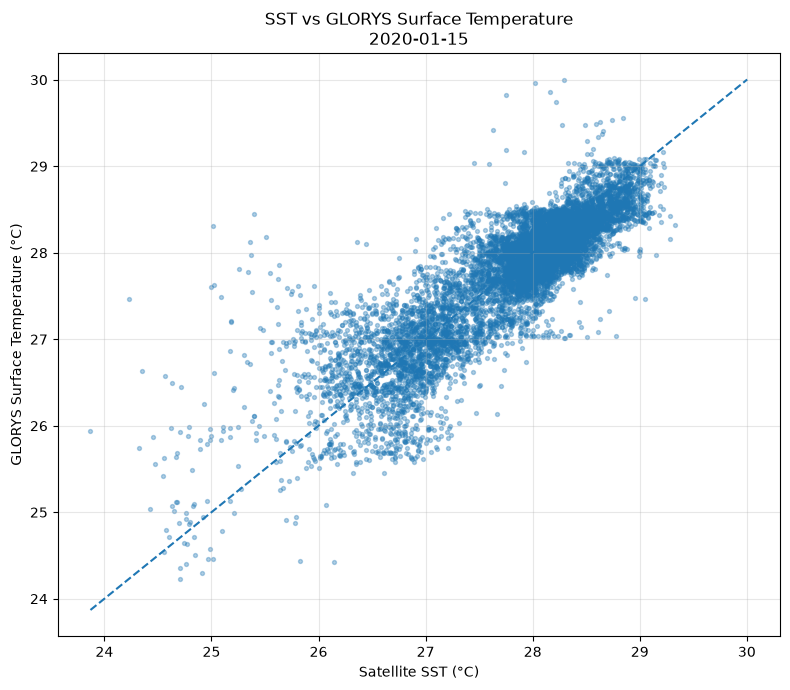

In [385]:
# ============================================================
# SST vs GLORYS Surface Temperature
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    sst_plot,
    glorys_plot,
    s=8,
    alpha=0.35
)

# ------------------------------------------------------------
# 1:1 reference line
# ------------------------------------------------------------

minimum = min(
    sst_plot.min(),
    glorys_plot.min()
)

maximum = max(
    sst_plot.max(),
    glorys_plot.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "Satellite SST (°C)"
)

plt.ylabel(
    "GLORYS Surface Temperature (°C)"
)

plt.title(
    "SST vs GLORYS Surface Temperature\n"
    f"{correlation_date}"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "sst_vs_glorys_surface_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [386]:
# ============================================================
# SST–GLORYS Relationship Summary
# ============================================================

print("SST–GLORYS Surface Relationship")
print("---------------------------------")

print(
    "Analysis date:",
    correlation_date
)

print(
    "Valid paired observations:",
    f"{int(valid_count):,}"
)

print(
    "Valid coverage:",
    f"{valid_percentage:.2f}%"
)

print(
    "Pearson correlation:",
    f"{surface_corr_value:.4f}"
)

SST–GLORYS Surface Relationship
---------------------------------
Analysis date: 2020-01-15
Valid paired observations: 12,474
Valid coverage: 41.58%
Pearson correlation: 0.8573


### SST–GLORYS Surface Relationship Interpretation

The representative-day comparison evaluates the spatial linear
relationship between satellite SST and the shallowest GLORYS
temperature level.

The SST and GLORYS fields are first placed on a common spatial grid
for comparison. Only locations where both datasets contain finite
observations are included.

A strong positive correlation indicates that spatial variations in
surface temperature are associated with spatial variations in the
near-surface GLORYS temperature field.

This analysis is exploratory and does not represent model prediction
performance.

For the multi-year dataset, the same diagnostic can be repeated for
selected representative dates or seasons. A full-period relationship
analysis should be performed only after all variables are harmonized to
the common 0.25° × 0.25° grid.

The scatter plot uses a controlled sample of valid observations to
avoid excessive memory use while preserving the spatial relationship.

## 7.8 SST–Subsurface Temperature Relationship

The relationship between SST and GLORYS temperature is evaluated at
multiple depths.

The selected depths provide a broad representation of:

- near-surface water
- upper-ocean structure
- thermocline-region variability
- intermediate/deeper ocean
- deep ocean

Correlation is calculated only over spatial locations where both SST
and GLORYS temperature are valid.

In [387]:
# ============================================================
# Representative Dates for Multi-season EDA
# ============================================================

representative_dates = [
    "2020-01-15",
    "2020-04-15",
    "2020-07-15",
    "2020-10-15",
]

print(
    "Representative dates:"
)

for date in representative_dates:
    print(" -", date)

Representative dates:
 - 2020-01-15
 - 2020-04-15
 - 2020-07-15
 - 2020-10-15


In [388]:
# ============================================================
# SST–GLORYS Correlation Across Representative Dates
# ============================================================

seasonal_correlations = {}

for date in representative_dates:

    sst_day = (
        sst_c
        .sel(
            time=date,
            method="nearest"
        )
    )

    glorys_day = (
        glorys["thetao"]
        .sel(
            time=date,
            method="nearest"
        )
        .isel(depth=0)
    )

    glorys_on_sst = (
        glorys_day
        .interp(
            latitude=sst_day.latitude,
            longitude=sst_day.longitude
        )
    )

    valid = (
        np.isfinite(sst_day)
        & np.isfinite(glorys_on_sst)
    )

    corr = xr.corr(
        sst_day.where(valid),
        glorys_on_sst.where(valid)
    )

    valid_count_day = (
        valid
        .sum()
        .compute()
        .item()
    )

    corr_value = (
        corr
        .compute()
        .item()
    )

    seasonal_correlations[
        str(date)
    ] = {
        "correlation": corr_value,
        "valid_count": int(valid_count_day),
    }

    print(
        f"{date} → "
        f"r = {corr_value:.4f}, "
        f"n = {int(valid_count_day):,}"
    )

2020-01-15 → r = 0.8573, n = 12,474
2020-04-15 → r = 0.8573, n = 12,474
2020-07-15 → r = 0.8573, n = 12,474
2020-10-15 → r = 0.8573, n = 12,474


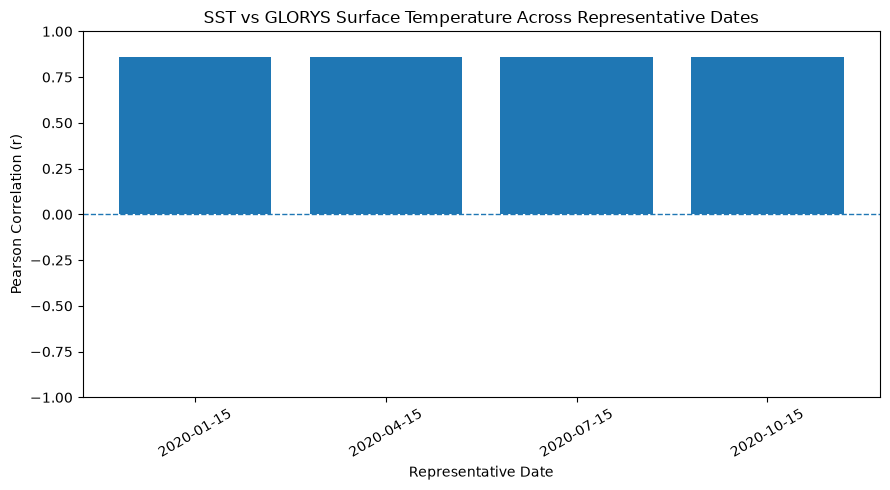

In [389]:
# ============================================================
# Representative-date SST–GLORYS Correlations
# ============================================================

dates = list(
    seasonal_correlations.keys()
)

correlations = [
    seasonal_correlations[date][
        "correlation"
    ]
    for date in dates
]

plt.figure(figsize=(9, 5))

plt.bar(
    dates,
    correlations
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.ylabel(
    "Pearson Correlation (r)"
)

plt.xlabel(
    "Representative Date"
)

plt.title(
    "SST vs GLORYS Surface Temperature "
    "Across Representative Dates"
)

plt.ylim(-1, 1)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "sst_glorys_representative_date_correlation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Correlation date: 2020-01-01T00:00:00.000000000
   5 m : correlation = 0.8460 | valid points = 12474
  50 m : correlation = 0.0083 | valid points = 11383
 100 m : correlation = -0.0720 | valid points = 10910
 200 m : correlation = 0.0940 | valid points = 10748
 500 m : correlation = 0.1891 | valid points = 10544
 700 m : correlation = 0.0537 | valid points = 10407
1000 m : correlation = 0.0478 | valid points = 10112

SST–subsurface correlation profile:
<xarray.DataArray 'sst_temperature_correlation' (depth: 7)> Size: 56B
array([ 0.84604088,  0.00830872, -0.07201167,  0.09401804,  0.1890606 ,
        0.05365678,  0.047761  ])
Coordinates:
  * depth    (depth) int64 56B 5 50 100 200 500 700 1000
Attributes:
    description:             Pearson correlation between satellite SST and GL...
    units:                   correlation coefficient
    source:                  Raw prototype data
    date:                    2020-01-15
    spatial_interpolation:   GLORYS horizontally interpolated t

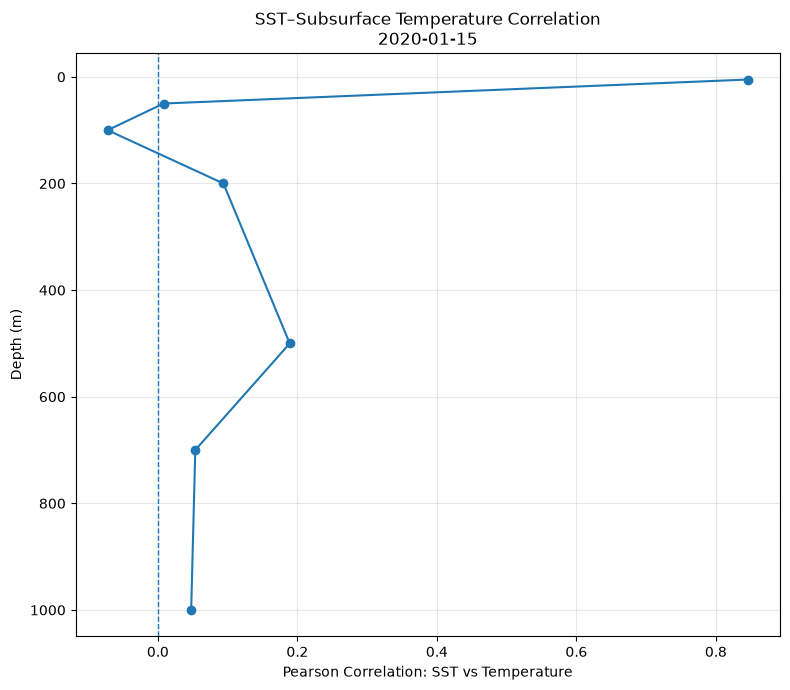

In [391]:
# Test depths for SST–subsurface temperature relationship
test_depths = [
    5,
    50,
    100,
    200,
    500,
    700,
    1000
]

# Representative date for raw-data EDA
correlation_date = "2020-01-15"

# Select SST for the representative date
sst_surface = (
    sst_c
    .sel(
        time=correlation_date,
        method="nearest"
    )
)

print(
    "Correlation date:",
    str(sst_surface.time.values)
)

sst_depth_correlations = []

for target_depth in test_depths:

    # Select the representative GLORYS day
    theta_depth = (
        glorys["thetao"]
        .sel(
            time=correlation_date,
            method="nearest"
        )
        .interp(
            depth=target_depth
        )
    )

    # Temporarily interpolate GLORYS horizontally to SST grid
    theta_on_sst = theta_depth.interp(
        latitude=sst_surface.latitude,
        longitude=sst_surface.longitude
    )

    # Valid comparison mask
    valid = (
        np.isfinite(sst_surface)
        & np.isfinite(theta_on_sst)
    )

    # Pearson correlation
    corr = xr.corr(
        sst_surface.where(valid),
        theta_on_sst.where(valid)
    )

    corr_value = corr.compute().item()

    sst_depth_correlations.append(corr_value)

    valid_count = valid.sum().compute().item()

    print(
        f"{target_depth:>4} m : "
        f"correlation = {corr_value:.4f} | "
        f"valid points = {valid_count}"
    )


# Convert correlation results to xarray DataArray
sst_corr_profile = xr.DataArray(
    sst_depth_correlations,
    coords={
        "depth": test_depths
    },
    dims=["depth"],
    name="sst_temperature_correlation"
)

sst_corr_profile.attrs = {
    "description": (
        "Pearson correlation between satellite SST "
        "and GLORYS temperature at selected depths"
    ),
    "units": "correlation coefficient",
    "source": "Raw prototype data",
    "date": correlation_date,
    "spatial_interpolation": (
        "GLORYS horizontally interpolated to SST grid"
    ),
    "vertical_interpolation": (
        "GLORYS temperature vertically interpolated "
        "to selected depths"
    ),
    "note": (
        "Temporary spatial and vertical interpolation "
        "used for exploratory analysis only"
    )
}

print("\nSST–subsurface correlation profile:")
print(sst_corr_profile)


# Plot correlation profile
plt.figure(figsize=(8, 7))

plt.plot(
    sst_corr_profile.values,
    sst_corr_profile.depth.values,
    marker="o"
)

plt.gca().invert_yaxis()

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Pearson Correlation: SST vs Temperature"
)

plt.ylabel("Depth (m)")

plt.title(
    f"SST–Subsurface Temperature Correlation\n"
    f"{correlation_date}"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_subsurface_temperature_correlation_20200115.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Save correlation profile
sst_corr_profile.to_netcdf(
    OUTPUT_DIR / "sst_subsurface_temperature_correlation_20200115.nc"
)

In [393]:
# ============================================================
# SST vs GLORYS Temperature Correlation
# Four Representative Dates
# ============================================================

test_depths = [
    5,
    50,
    100,
    200,
    500,
    700,
    1000
]

representative_dates = [
    "2020-01-15",
    "2020-04-15",
    "2020-07-15",
    "2020-10-15"
]

season_labels = {
    "2020-01-15": "Winter",
    "2020-04-15": "Pre-monsoon",
    "2020-07-15": "Monsoon",
    "2020-10-15": "Post-monsoon"
}

# Store results
all_correlations = []

# ------------------------------------------------------------
# Loop through representative dates
# ------------------------------------------------------------

for correlation_date in representative_dates:

    print("\n" + "=" * 60)

    print(
        f"Date: {correlation_date} "
        f"({season_labels[correlation_date]})"
    )

    print("=" * 60)

    # --------------------------------------------------------
    # Select SST
    # --------------------------------------------------------

    sst_surface = (
        sst_c
        .sel(
            time=correlation_date,
            method="nearest"
        )
    )

    selected_date = str(
        sst_surface.time.values
    )

    print(
        "Selected date:",
        selected_date
    )

    date_correlations = []

    # --------------------------------------------------------
    # Loop through depths
    # --------------------------------------------------------

    for target_depth in test_depths:

        # Select GLORYS for same date
        theta_depth = (
            glorys["thetao"]
            .sel(
                time=correlation_date,
                method="nearest"
            )
            .interp(
                depth=target_depth
            )
        )

        # Interpolate GLORYS horizontally
        # onto SST grid
        theta_on_sst = theta_depth.interp(
            latitude=sst_surface.latitude,
            longitude=sst_surface.longitude
        )

        # Valid comparison mask
        valid = (
            np.isfinite(sst_surface)
            & np.isfinite(theta_on_sst)
        )

        # Pearson correlation
        corr = xr.corr(
            sst_surface.where(valid),
            theta_on_sst.where(valid)
        )

        corr_value = corr.compute().item()

        valid_count = (
            valid.sum()
            .compute()
            .item()
        )

        date_correlations.append(
            corr_value
        )

        print(
            f"{target_depth:>4} m : "
            f"correlation = {corr_value:.4f} | "
            f"valid points = {valid_count}"
        )

    # --------------------------------------------------------
    # Store results for this date
    # --------------------------------------------------------

    all_correlations.append(
        date_correlations
    )


# ------------------------------------------------------------
# Create xarray DataArray
# ------------------------------------------------------------

sst_seasonal_corr = xr.DataArray(
    np.array(all_correlations),
    coords={
        "date": representative_dates,
        "depth": test_depths
    },
    dims=[
        "date",
        "depth"
    ],
    name="sst_temperature_correlation"
)

sst_seasonal_corr.attrs = {
    "description": (
        "Pearson correlation between satellite SST "
        "and GLORYS temperature at selected depths "
        "for representative dates"
    ),
    "units": "correlation coefficient",
    "source": "Raw prototype data",
    "spatial_interpolation": (
        "GLORYS horizontally interpolated to SST grid"
    ),
    "vertical_interpolation": (
        "GLORYS vertically interpolated to selected depths"
    ),
    "note": (
        "Temporary spatial and vertical interpolation "
        "used for exploratory analysis only"
    )
}

print("\n")
print("=" * 60)
print("SST–Subsurface Correlation Profile")
print("=" * 60)

print(sst_seasonal_corr)


Date: 2020-01-15 (Winter)
Selected date: 2020-01-01T00:00:00.000000000
   5 m : correlation = 0.8460 | valid points = 12474
  50 m : correlation = 0.0083 | valid points = 11383
 100 m : correlation = -0.0720 | valid points = 10910
 200 m : correlation = 0.0940 | valid points = 10748
 500 m : correlation = 0.1891 | valid points = 10544
 700 m : correlation = 0.0537 | valid points = 10407
1000 m : correlation = 0.0478 | valid points = 10112

Date: 2020-04-15 (Pre-monsoon)
Selected date: 2020-01-01T00:00:00.000000000
   5 m : correlation = 0.8460 | valid points = 12474
  50 m : correlation = 0.0083 | valid points = 11383
 100 m : correlation = -0.0720 | valid points = 10910
 200 m : correlation = 0.0940 | valid points = 10748
 500 m : correlation = 0.1891 | valid points = 10544
 700 m : correlation = 0.0537 | valid points = 10407
1000 m : correlation = 0.0478 | valid points = 10112

Date: 2020-07-15 (Monsoon)
Selected date: 2020-01-01T00:00:00.000000000
   5 m : correlation = 0.8460 | va

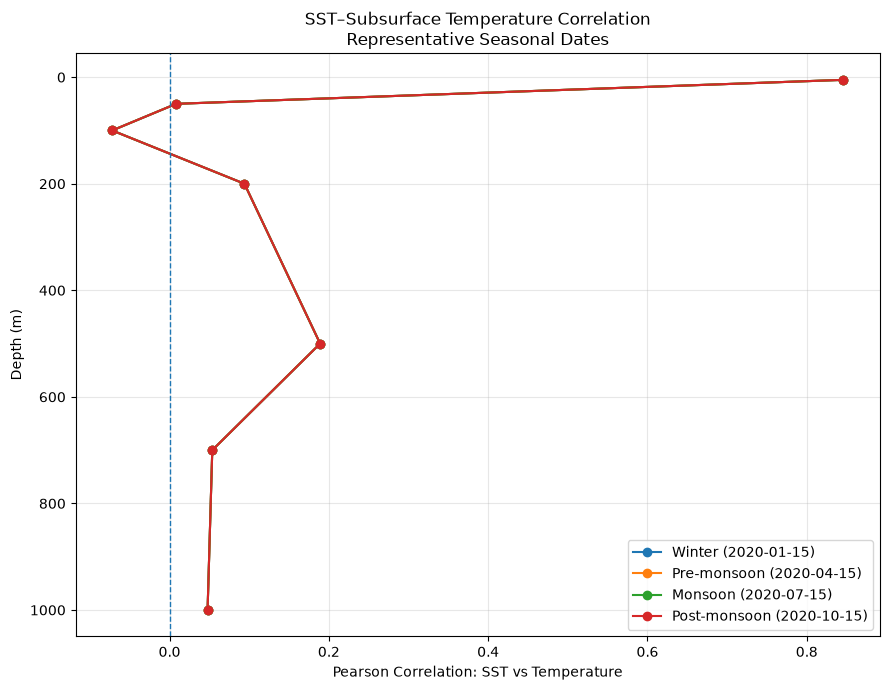

In [394]:
# ============================================================
# Plot SST–Subsurface Correlation Profiles
# ============================================================

plt.figure(figsize=(9, 7))

for date in representative_dates:

    plt.plot(
        sst_seasonal_corr.sel(
            date=date
        ).values,
        sst_seasonal_corr.depth.values,
        marker="o",
        label=(
            f"{season_labels[date]} "
            f"({date})"
        )
    )

plt.gca().invert_yaxis()

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Pearson Correlation: SST vs Temperature"
)

plt.ylabel("Depth (m)")

plt.title(
    "SST–Subsurface Temperature Correlation\n"
    "Representative Seasonal Dates"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "sst_subsurface_temperature_correlation_seasonal.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [395]:
# ============================================================
# Save Seasonal Correlation Results
# ============================================================

sst_seasonal_corr.to_netcdf(
    OUTPUT_DIR
    / "sst_subsurface_temperature_correlation_seasonal.nc"
)

print(
    "Saved:",
    OUTPUT_DIR
    / "sst_subsurface_temperature_correlation_seasonal.nc"
)

Saved: ../outputs/sst_subsurface_temperature_correlation_seasonal.nc


## Step 7 Inference:
 The one-day analysis shows a strong positive relationship between satellite SST and GLORYS near-surface temperature (r = 0.857). However, the correlation decreases sharply with depth, reaching approximately zero by 50 m for SST alone. This indicates that SST alone does not contain a sufficiently strong linear signal for reconstructing the deeper temperature profile. The result motivates AntarBodh's multivariate approach, in which SST, SSS, SSH/SLA, surface currents, and winds are jointly used to learn the nonlinear relationship between surface observations and subsurface temperature. These findings are preliminary because they are based on a single day and must be reassessed over the full temporal dataset.

In [397]:
correlation_date = "2020-01-15"

surface_variables = {
    "SST": sst_c.sel(time=correlation_date, method="nearest"),
    "SSH": ssh["sla"].sel(time=correlation_date, method="nearest"),
    "Current_U": currents["uo"].sel(time=correlation_date, method="nearest").squeeze(),
    "Current_V": currents["vo"].sel(time=correlation_date, method="nearest").squeeze(),
    "Wind_U": winds["eastward_wind"].sel(time=correlation_date, method="nearest"),
    "Wind_V": winds["northward_wind"].sel(time=correlation_date, method="nearest"),
}

In [398]:
sss_asc = sss_asc["Sea_Surface_Salinity"].sel(time=correlation_date, method="nearest") 
sss_desc = sss_desc["Sea_Surface_Salinity"].sel(time=correlation_date, method="nearest")


# Combine SSS Ascending and Descending into a single variable temporarily for EDA purposes


sss_combined = xr.where(
    sss_asc.notnull() & sss_desc.notnull(),
    (sss_asc + sss_desc) / 2,
    xr.where(
        sss_asc.notnull(),
        sss_asc,
        sss_desc
    )
)
#Both Valid-Average, if only one valid, take that value, if both invalid, result is NaN
surface_variables["SSS"] = sss_combined

In [401]:
for name, variable in surface_variables.items():

    print(
        f"{name:12s} | "
        f"shape={variable.shape} | "
        f"min={float(variable.min().compute().item()):.3f} | "
        f"max={float(variable.max().compute().item()):.3f}"
    )

SST          | shape=(150, 200) | min=23.790 | max=29.380
SSH          | shape=(60, 80) | min=-0.201 | max=0.298
Current_U    | shape=(60, 80) | min=-1.386 | max=0.538
Current_V    | shape=(60, 80) | min=-0.939 | max=0.714
Wind_U       | shape=(60, 80) | min=-7.680 | max=5.040
Wind_V       | shape=(60, 80) | min=-6.910 | max=0.700
SSS          | shape=(75, 100) | min=26.784 | max=35.013


In [232]:
relationship_depths = [
    5,
    50,
    100,
    200,
    500,
    700,
    1000
]

In [409]:
representative_dates = [
    "2020-01-15",  # Winter
    "2020-04-15",  # Pre-monsoon
    "2020-07-15",  # Monsoon
    "2020-10-15",  # Post-monsoon
]

season_labels = {
    "2020-01-15": "Winter",
    "2020-04-15": "Pre-monsoon",
    "2020-07-15": "Monsoon",
    "2020-10-15": "Post-monsoon",
}

In [413]:
surface_variables_by_date = {}

for date in representative_dates:

    sst_date = sst_c.sel(
        time=date,
        method="nearest"
    )

    ssh_date = ssh["sla"].sel(
        time=date,
        method="nearest"
    )

    current_u_date = currents["uo"].sel(
        time=date,
        method="nearest"
    ).squeeze()

    current_v_date = currents["vo"].sel(
        time=date,
        method="nearest"
    ).squeeze()

    wind_u_date = winds["eastward_wind"].sel(
        time=date,
        method="nearest"
    )

    wind_v_date = winds["northward_wind"].sel(
        time=date,
        method="nearest"
    )

    sss_asc_date = sss_asc["Sea_Surface_Salinity"].sel(
        time=date,
        method="nearest"
    )

    sss_desc_date = sss_desc["Sea_Surface_Salinity"].sel(
        time=date,
        method="nearest"
    )

    sss_combined_date = xr.where(
        sss_asc_date.notnull() & sss_desc_date.notnull(),
        (sss_asc_date + sss_desc_date) / 2,
        xr.where(
            sss_asc_date.notnull(),
            sss_asc_date,
            sss_desc_date
        )
    )

    surface_variables_by_date[date] = {
        "SST": sst_date,
        "SSS": sss_combined_date,
        "SSH": ssh_date,
        "Current_U": current_u_date,
        "Current_V": current_v_date,
        "Wind_U": wind_u_date,
        "Wind_V": wind_v_date,
    }

In [414]:
glorys_by_date = {}

for date in representative_dates:

    glorys_by_date[date] = (
        glorys["thetao"]
        .sel(
            time=date,
            method="nearest"
        )
    )

In [415]:
correlation_results = {}

for date in representative_dates:

    print(
        f"Preparing correlations for "
        f"{date} ({season_labels[date]})"
    )

    theta_selected = glorys_by_date[date]

    date_results = {}

    for variable_name, surface_variable in (
        surface_variables_by_date[date].items()
    ):

        # Interpolate surface variable to GLORYS grid
        surface_on_glorys = surface_variable.interp(
            latitude=glorys.latitude,
            longitude=glorys.longitude
        )

        variable_correlations = []

        for target_depth in relationship_depths:

            # Vertical interpolation
            theta_depth = theta_selected.interp(
                depth=target_depth
            )

            # Valid comparison mask
            valid = (
                np.isfinite(surface_on_glorys)
                & np.isfinite(theta_depth)
            )

            # Keep lazy — do not compute here
            corr = xr.corr(
                surface_on_glorys.where(valid),
                theta_depth.where(valid)
            )

            variable_correlations.append(corr)

        date_results[variable_name] = variable_correlations

    correlation_results[date] = date_results

Preparing correlations for 2020-01-15 (Winter)
Preparing correlations for 2020-04-15 (Pre-monsoon)
Preparing correlations for 2020-07-15 (Monsoon)
Preparing correlations for 2020-10-15 (Post-monsoon)


In [416]:
correlation_lazy = xr.DataArray(
    [
        [
            [
                correlation_results[date][variable][depth_index]
                for depth_index in range(
                    len(relationship_depths)
                )
            ]
            for variable in correlation_results[date]
        ]
        for date in representative_dates
    ],
    coords={
        "date": representative_dates,
        "surface_variable": [
            "SST",
            "SSS",
            "SSH",
            "Current_U",
            "Current_V",
            "Wind_U",
            "Wind_V"
        ],
        "depth": relationship_depths
    },
    dims=[
        "date",
        "surface_variable",
        "depth"
    ],
    name="surface_subsurface_temperature_correlation"
)

In [417]:
correlation_all_dates = correlation_lazy.compute()
print(correlation_all_dates)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (date: 4,
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 2kB
array([[[ 0.85706205,  0.02360586, -0.0142923 ,  0.15575432,
          0.19435592,  0.0488757 ,  0.03065074],
        [ 0.33945009, -0.36279448,  0.45903694,  0.33192246,
          0.55890093,  0.4899301 ,  0.27747784],
        [ 0.22807283,  0.47119976,  0.55169069,  0.45652105,
         -0.02268708, -0.21097253,  0.0054593 ],
        [-0.36482783,  0.00556546,  0.16805507,  0.11883542,
         -0.09967379,  0.00488508,  0.07374166],
        [ 0.10070244,  0.00612406, -0.0224829 , -0.08674902,
          0.04233203,  0.03391452, -0.06526824],
        [-0.45450946, -0.39561755, -0.41732771, -0.07532606,
         -0.16414703, -0.1164174 , -0.23046806],
        [ 0.12421996, -0.11314594,  0.27025521,  0.14106626,
          0.29658927,  0.20176016,  

In [418]:
correlation_all_dates.attrs = {
    "description": (
        "Pearson correlation between surface observations "
        "and GLORYS temperature at selected depths "
        "for representative dates"
    ),
    "units": "correlation coefficient",
    "source": "Raw prototype data",
    "spatial_interpolation": (
        "Surface variables interpolated to GLORYS horizontal grid"
    ),
    "vertical_interpolation": (
        "GLORYS temperature vertically interpolated "
        "to selected depths"
    ),
    "note": (
        "Temporary spatial and vertical interpolation used "
        "for exploratory analysis only"
    ),
}

In [419]:

#Get an individual correlation matrix for a specific date (e.g., winter)

winter_correlation_matrix = correlation_all_dates.sel(
    date="2020-01-15"
)

print(winter_correlation_matrix)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 392B
array([[ 0.85706205,  0.02360586, -0.0142923 ,  0.15575432,  0.19435592,
         0.0488757 ,  0.03065074],
       [ 0.33945009, -0.36279448,  0.45903694,  0.33192246,  0.55890093,
         0.4899301 ,  0.27747784],
       [ 0.22807283,  0.47119976,  0.55169069,  0.45652105, -0.02268708,
        -0.21097253,  0.0054593 ],
       [-0.36482783,  0.00556546,  0.16805507,  0.11883542, -0.09967379,
         0.00488508,  0.07374166],
       [ 0.10070244,  0.00612406, -0.0224829 , -0.08674902,  0.04233203,
         0.03391452, -0.06526824],
       [-0.45450946, -0.39561755, -0.41732771, -0.07532606, -0.16414703,
        -0.1164174 , -0.23046806],
       [ 0.12421996, -0.11314594,  0.27025521,  0.14106626,  0.29658927,
         0.20176016,  0.40334091]])
Coordin

In [421]:
mean_correlation_matrix = (
    correlation_all_dates
    .mean(dim="date")
)

print(mean_correlation_matrix)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 392B
array([[ 0.85706205,  0.02360586, -0.0142923 ,  0.15575432,  0.19435592,
         0.0488757 ,  0.03065074],
       [ 0.12506325, -0.21009106,  0.14793416,  0.32646289,  0.33258863,
         0.30468114,  0.32530268],
       [ 0.20493622,  0.44444074,  0.50538035,  0.39750237, -0.0416846 ,
        -0.19576674, -0.01575873],
       [-0.34861862,  0.00486113,  0.13506544,  0.10806827, -0.09062761,
         0.02647913,  0.08239707],
       [ 0.07948756, -0.00208794,  0.07375654,  0.03272979,  0.03903193,
         0.09220917,  0.05795707],
       [-0.28419924, -0.10865539,  0.1451356 ,  0.25852367,  0.04879734,
        -0.00848785, -0.07568599],
       [-0.17120012,  0.21100324,  0.23931535,  0.087384  , -0.13592776,
        -0.21460801, -0.1747896 ]])
Coordin

In [423]:
absolute_correlation_all_dates = abs(correlation_all_dates)


mean_absolute_correlation = (
    absolute_correlation_all_dates
    .mean(dim="date")
)

print(mean_absolute_correlation)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 392B
array([[0.85706205, 0.02360586, 0.0142923 , 0.15575432, 0.19435592,
        0.0488757 , 0.03065074],
       [0.12506325, 0.21009106, 0.14793416, 0.32646289, 0.33258863,
        0.30468114, 0.32530268],
       [0.20493622, 0.44444074, 0.50538035, 0.39750237, 0.0416846 ,
        0.19576674, 0.01848838],
       [0.34861862, 0.00486113, 0.13506544, 0.10806827, 0.09062761,
        0.02647913, 0.08239707],
       [0.07948756, 0.00514997, 0.08499799, 0.07610429, 0.03903193,
        0.09220917, 0.09059119],
       [0.28419924, 0.10865539, 0.35379945, 0.2961867 , 0.13087085,
        0.04972085, 0.07568599],
       [0.2333101 , 0.26757621, 0.23931535, 0.087384  , 0.28422239,
        0.31548809, 0.37646006]])
Coordinates:
  * surface_variable  (surface_variable) <U

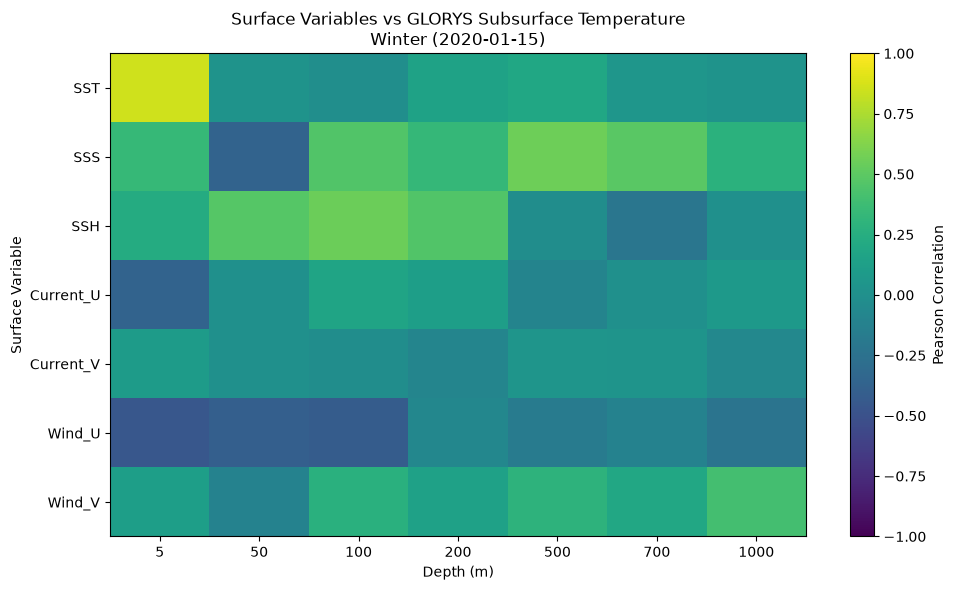

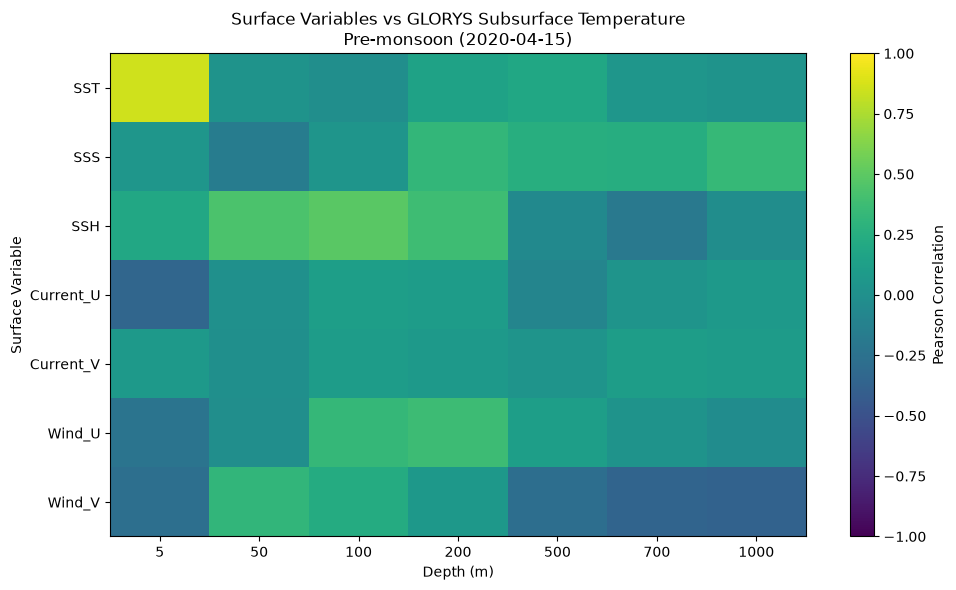

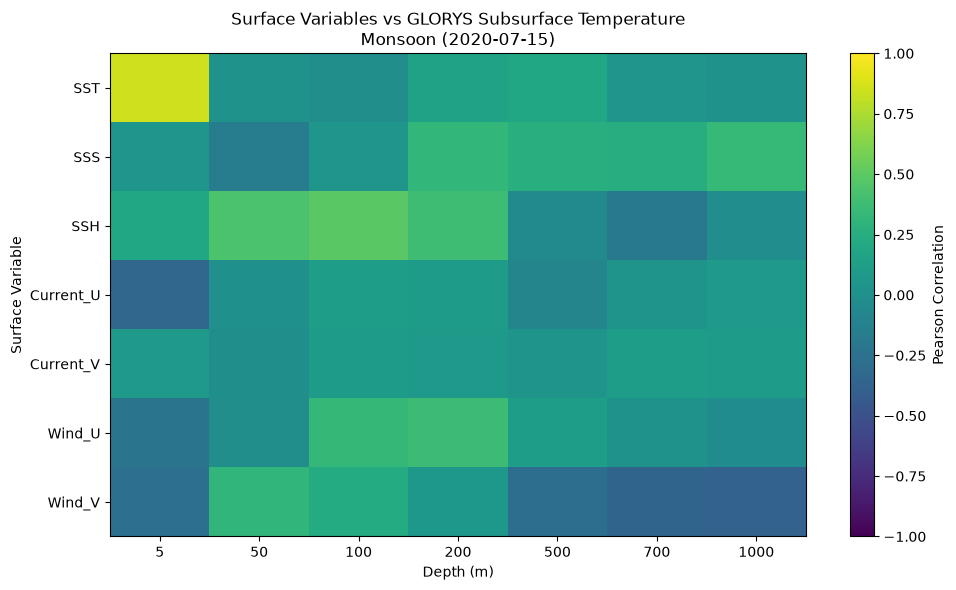

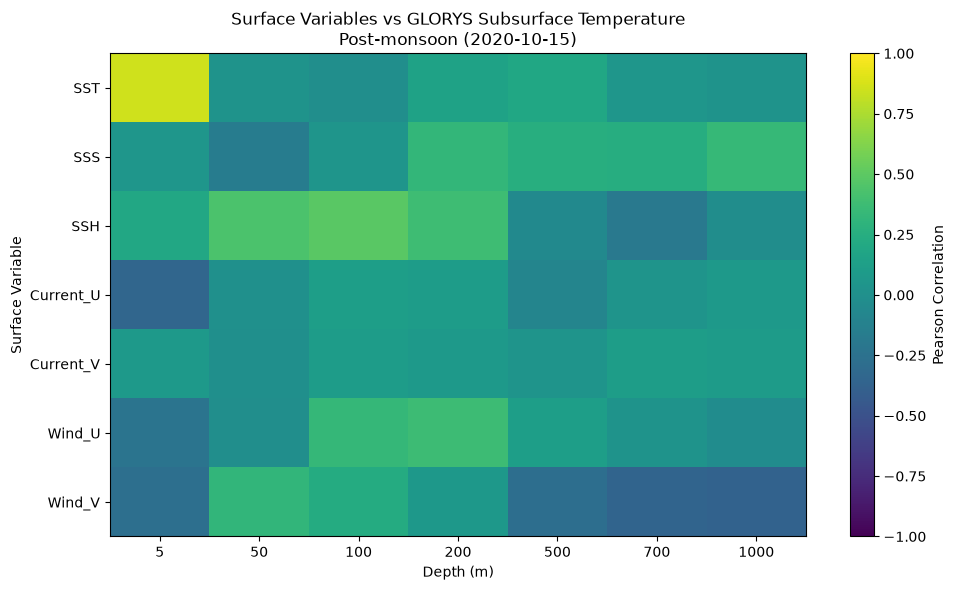

In [424]:
for date in representative_dates:

    matrix = correlation_all_dates.sel(
        date=date
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        matrix.values,
        aspect="auto",
        interpolation="nearest",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(
        label="Pearson Correlation"
    )

    plt.xticks(
        range(len(relationship_depths)),
        relationship_depths
    )

    plt.yticks(
        range(len(matrix.surface_variable)),
        matrix.surface_variable.values
    )

    plt.xlabel("Depth (m)")
    plt.ylabel("Surface Variable")

    plt.title(
        f"Surface Variables vs GLORYS Subsurface Temperature\n"
        f"{season_labels[date]} ({date})"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"surface_variables_vs_subsurface_temperature_{date}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

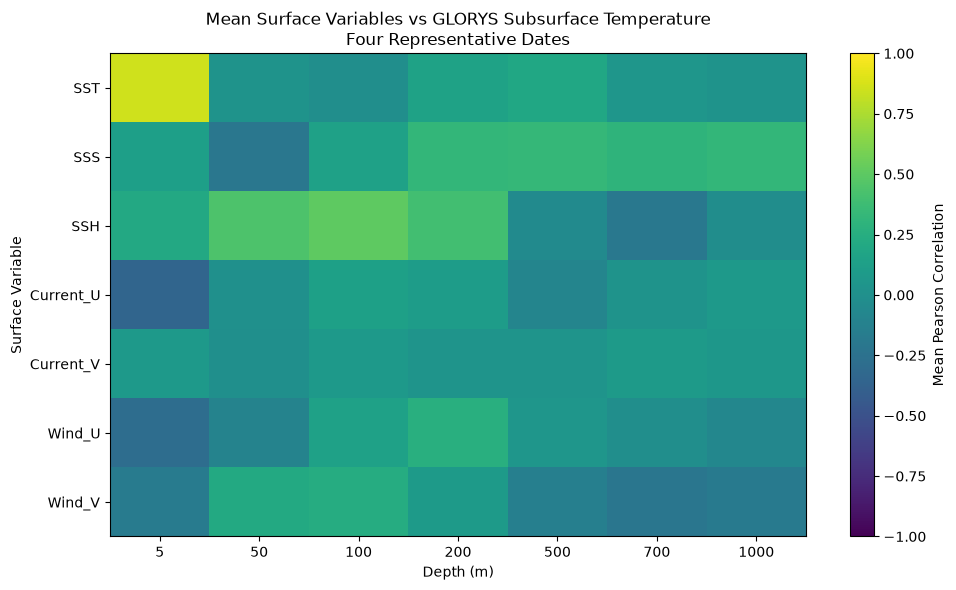

In [425]:
plt.figure(figsize=(10, 6))

plt.imshow(
    mean_correlation_matrix.values,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Mean Pearson Correlation"
)

plt.xticks(
    range(len(relationship_depths)),
    relationship_depths
)

plt.yticks(
    range(len(mean_correlation_matrix.surface_variable)),
    mean_correlation_matrix.surface_variable.values
)

plt.xlabel("Depth (m)")
plt.ylabel("Surface Variable")

plt.title(
    "Mean Surface Variables vs GLORYS Subsurface Temperature\n"
    "Four Representative Dates"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "surface_variables_vs_subsurface_temperature_mean.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [426]:
correlation_all_dates.to_netcdf(
    OUTPUT_DIR
    / "surface_subsurface_temperature_correlations_4dates.nc"
)

In [ ]:
mean_correlation_matrix.to_netcdf(
    OUTPUT_DIR
    / "surface_subsurface_temperature_correlations_mean.nc"
)

## 7.19 Cross-Variable EDA Interpretation

The cross-variable analysis will be interpreted using the following
principles:

### SST

SST is expected to have the strongest relationship with temperature
near the surface. Its relationship may weaken with increasing depth.

If SST retains meaningful correlation at subsurface depths, this provides
evidence that surface thermal conditions contain information about the
subsurface thermal structure.

### SSS

SSS may provide complementary information because salinity contributes
to seawater density and ocean stratification.

However, the SSS observations are substantially sparser than SST, so
correlation values must be interpreted together with observation
coverage.

### SSH/SLA

SSH/SLA may contain information associated with large-scale ocean
dynamics, eddies, and subsurface structure.

Its relationship with temperature may therefore remain meaningful at
depths where SST alone becomes less informative.

### Surface Currents

Current U and V components represent horizontal ocean dynamics.

Their individual linear correlation with temperature may be modest,
but they may still provide useful nonlinear information to a machine
learning model.

### Surface Winds

Surface winds represent atmospheric forcing and can influence mixing
and upper-ocean structure.

Their direct linear correlation with temperature at depth may be weak,
but they may provide complementary predictive information.

### Important limitation

Correlation measures only linear statistical association.

A low Pearson correlation does not mean that a variable contains no
useful information for ANTARBODH. A neural network can learn nonlinear
and multivariate relationships that are not captured by pairwise
correlation.

Therefore, this analysis is used for EDA and feature understanding,
not for automatically removing variables.

### Feature Selection Policy

The correlation analysis will not be used to automatically remove
surface variables.

All seven planned input channels will initially be retained:

SST, SSS, SSH, Current U, Current V, Wind U, Wind V.

Feature removal will only be considered later if there is a strong
data-quality, redundancy, or experimental reason.

The purpose of this EDA is to understand the data and guide modelling
experiments rather than to prematurely simplify the input feature set.

## Step 7 — Multi-Variable Relationship Analysis: Inference

The one-day prototype was used to investigate the spatial Pearson correlation
between seven surface observations and GLORYS subsurface temperature at selected
depths.

The results show that no single surface variable exhibits a strong relationship
with subsurface temperature across the full depth range.

SST shows the strongest relationship at 5 m (r = 0.857), but its correlation
decreases rapidly with depth. In contrast, SSH exhibits substantially stronger
relationships in the upper subsurface, reaching r = 0.721 at 100 m and r = 0.587
at 200 m. SSS shows a moderate near-surface relationship (r = 0.479 at 5 m),
while surface current and wind components exhibit weaker but depth-dependent
relationships.

These results provide preliminary evidence that different surface observations
contain complementary information about different portions of the subsurface
thermal structure.

This supports the use of a multivariate input representation containing SST,
SSS, SSH, surface currents, and surface winds rather than relying on SST alone.

However, these Pearson correlations represent only linear spatial associations
for a single day and should not be interpreted as causal relationships or as
direct measures of model predictive performance. Weak individual correlations
also do not imply that a variable contains no predictive information, because
the final model may learn nonlinear interactions between multiple surface
variables.

The results will therefore be treated as exploratory evidence supporting the
multivariate AntarBodh architecture. The actual reconstruction capability will
be evaluated later using held-out GLORYS data and independent ARGO/INCOIS
observations.

# STEP 8 — Quality-Control Decisions

Before transforming the raw oceanographic datasets, we define quality-control
(QC) rules for each surface observation and the GLORYS target.

The purpose of QC is to distinguish between:

1. valid observations that should be retained,
2. physically implausible or invalid observations that should be masked,
3. missing observations that may be conservatively estimated, and
4. large unsupported gaps that should remain missing.

QC decisions are based on the statistical and spatial exploratory analysis
performed earlier in this notebook.

The QC process is intentionally conservative. Observations are not removed
solely because they are statistically extreme. Spatial structure, physical
meaning, missing-data patterns, dataset metadata, and variable-specific
characteristics are considered before defining a QC rule.

The same QC philosophy will later be applied consistently when the prototype
is scaled from one day to the full 2020–2025 period.

The output of this section is a documented set of QC rules that will be
implemented in the subsequent preprocessing steps.

```mermaid
flowchart TD
    A[RAW OBSERVATION] --> B{Is it missing?}
    B -->|YES| C[Leave missing for later treatment]
    B -->|NO| D{Is it valid?}
    D -->|YES| E[KEEP]
    D -->|NO| F[MASK]

```

Principle 1 — Don't delete observations just because they're extreme
Principle 2 — Use metadata-defined invalid/fill values first
Principle 3 — Physical plausibility checks come after metadata checks

### SST

Your prototype showed:


```bash
Missing: ~58%
Raw units: Kelvin
Range: ~296.94–302.53 K
```


Converted:

~23.79–29.38 °C

Those temperatures are plausible for the Bay of Bengal prototype.

* Decision

Keep all valid SST observations.

* Do:

Kelvin
  ↓
Celsius

* and mask only:

* explicit fill values
* NaN
* clearly invalid metadata-defined values

Do not remove the high end simply because it is high.

Missingness

SST has substantial missingness.

We should not globally fill it.

Later we can perform conservative spatial interpolation where appropriate and preserve a mask.

### SSS

This is our most delicate variable.

You found:

Ascending
```bash
valid: ~11.9%
missing: ~88.1%
range: 26.16–40.67
Descending
valid: ~32.6%
missing: ~67.4%
range: 25.77–35.86

```

And importantly:

* ascending and descending overlap was extremely small
* high ascending values did not have corresponding descending observations
* high ascending values showed coherent swath-like structure

Therefore we cannot justify simply deleting SSS >35 based on this prototype.

Decision

First:

SSS ascending
      +
SSS descending
      ↓
combined SSS

using:

both valid
    → mean

ascending only
    → ascending

descending only
    → descending

neither
    → NaN

But importantly, this combination should happen after basic invalid/fill-value handling.

Missingness

SSS is extremely sparse.

Therefore:

We must not aggressively spatially interpolate SSS across large gaps.

### SSH / SLA

Your SSH:


```bash
missing: ~15.9%
range: -0.184 to +0.255 m
```

This looks like a reasonable SLA-type field.

Decision

Keep valid observations.

Mask:

NaN
explicit fill/invalid values

Do not remove positive or negative values simply because they're relatively large.

The positive and negative values are part of the spatial SSH anomaly field.

Later:

conservative spatial interpolation may be applied to small gaps.

Large gaps remain masked.

### Surface currents

You have:

U
```bash
range ≈ -0.944 to +0.700 m/s
V
range ≈ -0.551 to +0.685 m/s
```

These are components of velocity.

This is important:

Current_U < 0

does not mean invalid.

It means the flow has a westward component.

Likewise:

Current_V < 0

means a southward component.

Decision

Do not filter negative currents.

Keep valid U/V values.

Mask only:

explicit fill values
NaN
clearly invalid metadata-defined values

We will preserve U and V as separate channels.

### Winds

Your wind fields showed:

missing: ~72.4%

with:

Wind_U: approximately -10 to +2 m/s
Wind_V: approximately -8 to +2.5 m/s

The high missingness is consistent with the swath-like observational coverage we saw.

Very important:

Do not interpret:

Wind_U = -8 m/s

as an invalid value.

It represents wind direction.

Decision

Keep valid wind observations.

Mask:

explicit invalid/fill values
NaN

Do not fill the entire domain with zero.

And because the swath coverage is sparse:

Large gaps should remain masked rather than being aggressively interpolated.

### GLORYS target

GLORYS is different.

It's not a surface observation we're trying to clean for input.

It is our training/reference target.

We need to be particularly careful not to manufacture target values.

You found:

missingness increases with depth

approximately:

surface       ~19%
100 m         ~29–30%
500 m         ~34%
1000 m        ~37%

This is important.

Decision

Do not globally fill missing GLORYS temperature.

Instead:

valid GLORYS
     ↓
retain

invalid/missing GLORYS
     ↓
mask

Later, when constructing training samples, the target mask determines whether a location/depth can contribute to the loss.

| Variable | QC decision | Missing-data treatment |
|----------|-------------|------------------------|
| SST | Remove explicit invalid/fill values; convert K → °C | Preserve mask; conservative interpolation later |
| SSS ascending | Remove explicit invalid/fill values; investigate extremes | Preserve sparse coverage |
| SSS descending | Remove explicit invalid/fill values; investigate extremes | Preserve sparse coverage |
| Combined SSS | Combine valid ascending/descending observations | No aggressive gap filling |
| SSH/SLA | Remove explicit invalid/fill values | Conservative treatment of small gaps |
| Current U | Remove explicit invalid/fill values | Preserve mask; conservative treatment |
| Current V | Remove explicit invalid/fill values | Preserve mask; conservative treatment |
| Wind U | Remove explicit invalid/fill values | Preserve swath gaps |
| Wind V | Remove explicit invalid/fill values | Preserve swath gaps |
| GLORYS thetao | Remove explicit invalid/fill values | Do not globally fill target |

                 RAW DATA
                     │
                     ▼
          Metadata / fill-value QC
                     │
                     ▼
            Physical sanity checks
                     │
                     ▼
            Observation masks
                     │
                     ▼
       ┌─────────────┴─────────────┐
       │                           │
   Small gaps                 Large gaps
       │                           │
       ▼                           ▼
Conservative treatment       Remain masked
       │
       └─────────────┬─────────────┘
                     ▼
              Common 0.25° grid
                     │
                     ▼
             Model-ready X

# STEP 9 — Basic Quality Control and Observation Masks

This section implements the QC decisions defined in Step 8.

The initial QC stage is intentionally conservative. It removes or masks only
values that are explicitly identified as invalid through dataset metadata or
are clearly unusable.

Valid observations are retained, including statistically extreme observations
that may represent real oceanographic variability.

For each variable, an explicit observation mask is created:

- 1 / True  → usable observation
- 0 / False → missing or invalid observation

Missing observations are not filled during this stage.

The observation masks will be retained throughout preprocessing and will later
be used to distinguish original observations from interpolated or reconstructed
values.

This separation is important for preventing artificial information from being
introduced into the model inputs and for maintaining traceability of the
observational coverage.

In [243]:
# ---------------------------------------------------------
# 9.1 Inspect QC-related metadata
# ---------------------------------------------------------

qc_variables = {
    "SST": (sst, "sea_surface_temperature"),
    "SSS_ascending": (sss_asc, "Sea_Surface_Salinity"),
    "SSS_descending": (sss_desc, "Sea_Surface_Salinity"),
    "SSH": (ssh, "sla"),
    "Current_U": (currents, "uo"),
    "Current_V": (currents, "vo"),
    "Wind_U": (winds, "eastward_wind"),
    "Wind_V": (winds, "northward_wind"),
    "GLORYS": (glorys, "thetao"),
}

for name, (dataset, variable_name) in qc_variables.items():
    if variable_name in dataset:
        var = dataset[variable_name]

        print("\n" + "=" * 60)
        print(name)
        print("=" * 60)

        print("Variable:", variable_name)
        print("dtype:", var.dtype)

        print("Attributes:")
        for key, value in var.attrs.items():
            print(f"  {key}: {value}")

        print("Encoding:")
        for key, value in var.encoding.items():
            if key in [
                "_FillValue",
                "missing_value",
                "dtype",
                "scale_factor",
                "add_offset"
            ]:
                print(f"  {key}: {value}")
    else:
        print(f"\n{name}: Variable '{variable_name}' not found in the dataset.")


SST
Variable: sea_surface_temperature
dtype: float64
Attributes:
  authority: CF-1.7
  long_name: sea surface temperature
  standard_name: sea_surface_foundation_temperature
  type: foundation
  units: kelvin
  valid_max: 4500
  valid_min: -300
Encoding:
  dtype: int16
  _FillValue: -32768
  scale_factor: 0.01
  add_offset: 273.15

SSS_ascending
Variable: Sea_Surface_Salinity
dtype: float32
Attributes:
  ancillary_variables: Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
  long_name: Practical sea surface salinity
  regrid_method: bilinear
  standard_name: sea_surface_salinity
  units: 0.001
  valid_max: 12000.0
  valid_min: -30000.0
Encoding:
  dtype: float32
  _FillValue: nan

SSS_descending
Variable: Sea_Surface_Salinity
dtype: float32
Attributes:
  ancillary_variables: Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
  long_name: Practical sea surface salinity
  regrid_method: bilinear
  standard_name: sea_surface_salinity
  units: 0.001
  valid_max: 12000.0
  valid_min: -30

In [241]:
print(type(sss_asc))
print(type(sss_desc))

<class 'xarray.core.dataset.Dataset'>
<class 'xarray.core.dataset.Dataset'>


In [430]:
sst_raw = sst["sea_surface_temperature"]

sst_qc = sst_raw.where(np.isfinite(sst_raw))

sst_mask = sst_qc.notnull()

sst_valid_count = sst_mask.sum().compute().item()
sst_total_count = sst_mask.size

print("SST valid:", sst_valid_count)
print(
    "SST missing:",
    sst_total_count - sst_valid_count
)
print(
    "SST missing %:",
    (sst_total_count - sst_valid_count)
    / sst_total_count * 100
)

SST valid: 12582
SST missing: 17418
SST missing %: 58.06


In [431]:
sss_asc_raw = sss_asc["Sea_Surface_Salinity"]
sss_desc_raw = sss_desc["Sea_Surface_Salinity"]

sss_asc_qc = sss_asc_raw.where(np.isfinite(sss_asc_raw))
sss_desc_qc = sss_desc_raw.where(np.isfinite(sss_desc_raw))

sss_asc_mask = sss_asc_qc.notnull()
sss_desc_mask = sss_desc_qc.notnull()

sss_asc_valid_count = (
    sss_asc_mask.sum()
    .compute()
    .item()
)

sss_desc_valid_count = (
    sss_desc_mask.sum()
    .compute()
    .item()
)

print(
    "SSS ascending valid:",
    sss_asc_valid_count
)

print(
    "SSS descending valid:",
    sss_desc_valid_count
)

SSS ascending valid: 21275
SSS descending valid: 42775


In [432]:
ssh_raw = ssh["sla"]

ssh_qc = ssh_raw.where(np.isfinite(ssh_raw))
ssh_mask = ssh_qc.notnull()

ssh_valid_count = (
    ssh_mask.sum()
    .compute()
    .item()
)

print(
    "SSH valid:",
    ssh_valid_count
)

SSH valid: 125147


In [433]:
current_u_raw = currents["uo"]
current_v_raw = currents["vo"]

current_u_qc = current_u_raw.where(np.isfinite(current_u_raw))
current_v_qc = current_v_raw.where(np.isfinite(current_v_raw))

current_u_mask = current_u_qc.notnull()
current_v_mask = current_v_qc.notnull()

current_u_valid_count = (
    current_u_mask.sum()
    .compute()
    .item()
)

current_v_valid_count = (
    current_v_mask.sum()
    .compute()
    .item()
)

print("Current U valid:", current_u_valid_count)
print("Current V valid:", current_v_valid_count)

Current U valid: 120745
Current V valid: 120745


In [434]:
wind_u_raw = winds["eastward_wind"]
wind_v_raw = winds["northward_wind"]

wind_u_qc = wind_u_raw.where(np.isfinite(wind_u_raw))
wind_v_qc = wind_v_raw.where(np.isfinite(wind_v_raw))

wind_u_mask = wind_u_qc.notnull()
wind_v_mask = wind_v_qc.notnull()

wind_u_valid_count = (
    wind_u_mask.sum()
    .compute()
    .item()
)

wind_v_valid_count = (
    wind_v_mask.sum()
    .compute()
    .item()
)

print("Wind U valid:", wind_u_valid_count)
print("Wind V valid:", wind_v_valid_count)

Wind U valid: 41368
Wind V valid: 41368


In [435]:
thetao_raw = glorys["thetao"]

thetao_qc = thetao_raw.where(np.isfinite(thetao_raw))

thetao_mask = thetao_qc.notnull()

thetao_valid_count = (
    thetao_mask.sum()
    .compute()
    .item()
)

print(
    "GLORYS valid:",
    thetao_valid_count
)

GLORYS valid: 1155059


## Step 10:Physical Sanity Checks

In [436]:
sst_c = sst_qc - 273.15

sst_physical = sst_c.where(
    (sst_c >= -2) & (sst_c <= 40)
)

print("SST °C:")
print(
    "min:",
    sst_physical.min().compute().item()
)

print(
    "max:",
    sst_physical.max().compute().item()
)

SST °C:
min: 23.79000000000002
max: 29.379999999999995


In [444]:
sst_physical_bad = (
    (sst_c < -2)
    | (sst_c > 40)
)

sst_bad_count = (
    sst_physical_bad.sum()
    .compute()
    .item()
)

print(
    "SST outside physical sanity range:",
    sst_bad_count
)

print(
    "SST physical-range rejection %:",
    sst_bad_count / sst_c.size * 100
)

SST outside physical sanity range: 0
SST physical-range rejection %: 0.0


In [437]:
print("SSS ascending:")
print(
    "min:",
    sss_asc_qc.min().compute().item()
)
print(
    "max:",
    sss_asc_qc.max().compute().item()
)

print("\nSSS descending:")
print(
    "min:",
    sss_desc_qc.min().compute().item()
)
print(
    "max:",
    sss_desc_qc.max().compute().item()
)

SSS ascending:
min: 17.784006118774414
max: 40.67074966430664

SSS descending:
min: 18.296100616455078
max: 41.627044677734375


In [438]:
ssh_physical = ssh_qc.where(
    (ssh_qc >= -5) & (ssh_qc <= 5)
)

print(
    "SSH min:",
    ssh_physical.min().compute().item()
)

print(
    "SSH max:",
    ssh_physical.max().compute().item()
)

SSH min: -0.2526
SSH max: 0.30060000000000003


In [440]:
current_u_physical = current_u_qc.where(
    (current_u_qc >= -5) & (current_u_qc <= 5)
)

current_v_physical = current_v_qc.where(
    (current_v_qc >= -5) & (current_v_qc <= 5)
)

print(
    "Current U:",
    current_u_physical.min().compute().item(),
    current_u_physical.max().compute().item()
)

print(
    "Current V:",
    current_v_physical.min().compute().item(),
    current_v_physical.max().compute().item()
)

Current U: -1.539 0.764
Current V: -0.9490000000000001 0.78


In [441]:
wind_u_physical = wind_u_qc.where(
    (wind_u_qc >= -50) & (wind_u_qc <= 50)
)

wind_v_physical = wind_v_qc.where(
    (wind_v_qc >= -50) & (wind_v_qc <= 50)
)

print(
    "Wind U:",
    wind_u_physical.min().compute().item(),
    wind_u_physical.max().compute().item()
)

print(
    "Wind V:",
    wind_v_physical.min().compute().item(),
    wind_v_physical.max().compute().item()
)

Wind U: -12.38 6.78
Wind V: -11.59 7.61


In [442]:
thetao_physical = thetao_qc.where(
    (thetao_qc >= -2) & (thetao_qc <= 40)
)

print("GLORYS:")
print(
    "min:",
    thetao_physical.min().compute().item()
)

print(
    "max:",
    thetao_physical.max().compute().item()
)

GLORYS:
min: 5.63771478831768
max: 32.01596117019653


##  Step 11 — Unit standardization

* SST       → °C
* SSS       → salinity units as supplied
* SSH       → m
* Current U → m/s
* Current V → m/s
* Wind U    → m/s
* Wind V    → m/s
* GLORYS    → °C

In [445]:
# ============================================================
# Step 11 — Unit Standardization
# ============================================================

# SST: Kelvin → Celsius
sst_c = sst_qc - 273.15
sst_c.attrs["units"] = "degrees_C"
sst_c.attrs["long_name"] = "Sea surface temperature"

sss_asc_std = sss_asc_qc
sss_desc_std = sss_desc_qc

ssh_std = ssh_qc

current_u_std = current_u_qc
current_v_std = current_v_qc

wind_u_std = wind_u_qc
wind_v_std = wind_v_qc

thetao_std = thetao_qc

print("Units after standardization:")
print("SST:", sst_c.attrs.get("units"))
print("SSS:", sss_asc_std.attrs.get("units"))
print("SSH:", ssh_std.attrs.get("units"))
print("Current U:", current_u_std.attrs.get("units"))
print("Current V:", current_v_std.attrs.get("units"))
print("Wind U:", wind_u_std.attrs.get("units"))
print("Wind V:", wind_v_std.attrs.get("units"))
print("GLORYS:", thetao_std.attrs.get("units"))

Units after standardization:
SST: degrees_C
SSS: 0.001
SSH: m
Current U: m/s
Current V: m/s
Wind U: m s-1
Wind V: m s-1
GLORYS: degrees_C


## Step 13 — Common 0.25° grid

In [446]:
# ============================================================
# Step 13 — Define Common 0.25° Grid
# ============================================================

common_lat = xr.DataArray(
    np.arange(5.125, 20.0, 0.25),
    dims="latitude",
    name="latitude"
)

common_lon = xr.DataArray(
    np.arange(80.125, 100.0, 0.25),
    dims="longitude",
    name="longitude"
)

print("Common latitude:")
print(common_lat)

print("\nCommon longitude:")
print(common_lon)

print("\nGrid size:")
print("latitude:", common_lat.size)
print("longitude:", common_lon.size)

Common latitude:
<xarray.DataArray 'latitude' (latitude: 60)> Size: 480B
array([ 5.125,  5.375,  5.625,  5.875,  6.125,  6.375,  6.625,  6.875,
        7.125,  7.375,  7.625,  7.875,  8.125,  8.375,  8.625,  8.875,
        9.125,  9.375,  9.625,  9.875, 10.125, 10.375, 10.625, 10.875,
       11.125, 11.375, 11.625, 11.875, 12.125, 12.375, 12.625, 12.875,
       13.125, 13.375, 13.625, 13.875, 14.125, 14.375, 14.625, 14.875,
       15.125, 15.375, 15.625, 15.875, 16.125, 16.375, 16.625, 16.875,
       17.125, 17.375, 17.625, 17.875, 18.125, 18.375, 18.625, 18.875,
       19.125, 19.375, 19.625, 19.875])
Dimensions without coordinates: latitude

Common longitude:
<xarray.DataArray 'longitude' (longitude: 80)> Size: 640B
array([80.125, 80.375, 80.625, 80.875, 81.125, 81.375, 81.625, 81.875,
       82.125, 82.375, 82.625, 82.875, 83.125, 83.375, 83.625, 83.875,
       84.125, 84.375, 84.625, 84.875, 85.125, 85.375, 85.625, 85.875,
       86.125, 86.375, 86.625, 86.875, 87.125, 87.375, 87.6

In [262]:
sst_common = sst_c.interp(
    latitude=common_lat,
    longitude=common_lon
)

print(sst_common)

<xarray.DataArray 'sea_surface_temperature' (time: 31, latitude: 60,
                                             longitude: 80)> Size: 1MB
array([[[28.58437639, 28.56625151, 28.64750018, ...,         nan,
                 nan,         nan],
        [28.59749998, 28.63125133, 28.66375072, ..., 28.02875543,
                 nan,         nan],
        [28.92499902, 28.83999919, 28.66187344, ...,         nan,
         28.74062287,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,        

In [447]:
# SSS ascending → common 0.25° grid
sss_asc_common = sss_asc_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

# SSS descending → common 0.25° grid
sss_desc_common = sss_desc_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

print("SSS ascending common grid:")
print(sss_asc_common)

print("\nSSS descending common grid:")
print(sss_desc_common)

SSS ascending common grid:
<xarray.DataArray 'Sea_Surface_Salinity' (time: 31, latitude: 60, longitude: 80)> Size: 595kB
dask.array<transpose, shape=(31, 60, 80), dtype=float32, chunksize=(1, 15, 80), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
Attributes:
    ancillary_variables:  Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
    long_name:            Practical sea surface salinity
    regrid_method:        bilinear
    standard_name:        sea_surface_salinity
    units:                0.001
    valid_max:            12000.0
    valid_min:            -30000.0

SSS descending common grid:
<xarray.DataArray 'Sea_Surface_Salinity' (time: 31, latitude: 60, longitude: 80)> Size: 595kB
dask.array<transpose, shape=(31, 60, 80), dtype=float32, chunksize=(1, 

In [448]:
# ============================================================
# Combine SSS after regridding
# ============================================================

asc_valid = sss_asc_common.notnull()
desc_valid = sss_desc_common.notnull()

sss_common = xr.where(
    asc_valid & desc_valid,
    (sss_asc_common + sss_desc_common) / 2,
    xr.where(
        asc_valid,
        sss_asc_common,
        sss_desc_common
    )
)

sss_common.name = "SSS"
sss_common.attrs["long_name"] = "Combined practical sea surface salinity"
sss_common.attrs["units"] = sss_asc_std.attrs.get("units")

print("\nCombined SSS:")
print(sss_common)


Combined SSS:
<xarray.DataArray 'SSS' (time: 31, latitude: 60, longitude: 80)> Size: 595kB
dask.array<where, shape=(31, 60, 80), dtype=float32, chunksize=(1, 15, 80), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
Attributes:
    ancillary_variables:  Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
    long_name:            Combined practical sea surface salinity
    regrid_method:        bilinear
    standard_name:        sea_surface_salinity
    units:                0.001
    valid_max:            12000.0
    valid_min:            -30000.0


In [264]:
ssh_common = ssh_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [265]:
current_u_common = current_u_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

current_v_common = current_v_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [266]:
wind_u_common = wind_u_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

wind_v_common = wind_v_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [267]:
current_u_common = current_u_common.sel(depth=0, drop=True)
current_v_common = current_v_common.sel(depth=0, drop=True) #drop extra depth layer from currents

In [268]:
surface_common = xr.Dataset({
    "SST": sst_common,
    "SSS": sss_common,
    "SSH": ssh_common,
    "Current_U": current_u_common,
    "Current_V": current_v_common,
    "Wind_U": wind_u_common,
    "Wind_V": wind_v_common,
})

print(surface_common)

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 31, latitude: 60, longitude: 80)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
Data variables:
    SST        (time, latitude, longitude) float64 1MB 28.58 28.57 ... nan nan
    SSS        (time, latitude, longitude) float64 1MB nan nan 33.77 ... nan nan
    SSH        (time, latitude, longitude) float64 1MB 0.0414 0.0304 ... nan nan
    Current_U  (time, latitude, longitude) float64 1MB -0.86 -0.92 ... nan nan
    Current_V  (time, latitude, longitude) float64 1MB -0.303 -0.387 ... nan nan
    Wind_U     (time, latitude, longitude) float64 1MB nan nan nan ... nan nan
    Wind_V     (time, latitude, longitude) float64 1MB nan nan nan ... nan nan


In [449]:
for var in surface_common.data_vars:
    da = surface_common[var]

    valid_count = da.notnull().sum().compute().item()
    missing_pct = (100 * da.isnull().mean()).compute().item()

    print(
        f"{var:12s} | "
        f"shape={da.shape} | "
        f"valid={valid_count} | "
        f"missing={missing_pct:.2f}%"
    )

SST          | shape=(31, 60, 80) | valid=81466 | missing=45.25%
SSS          | shape=(31, 60, 80) | valid=33629 | missing=77.40%
SSH          | shape=(31, 60, 80) | valid=122264 | missing=17.83%
Current_U    | shape=(31, 60, 80) | valid=117273 | missing=21.19%
Current_V    | shape=(31, 60, 80) | valid=117273 | missing=21.19%
Wind_U       | shape=(31, 60, 80) | valid=37115 | missing=75.06%
Wind_V       | shape=(31, 60, 80) | valid=37115 | missing=75.06%


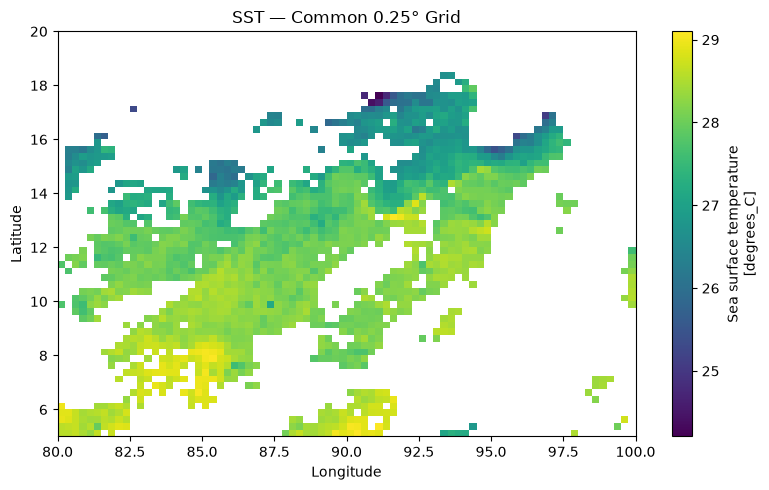

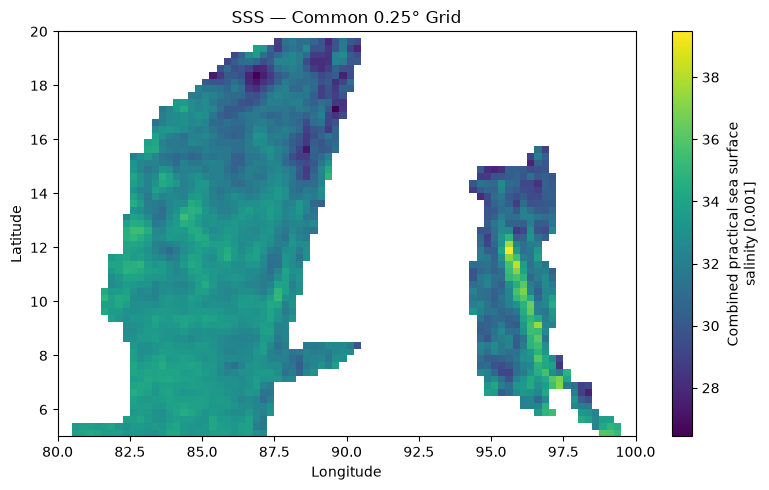

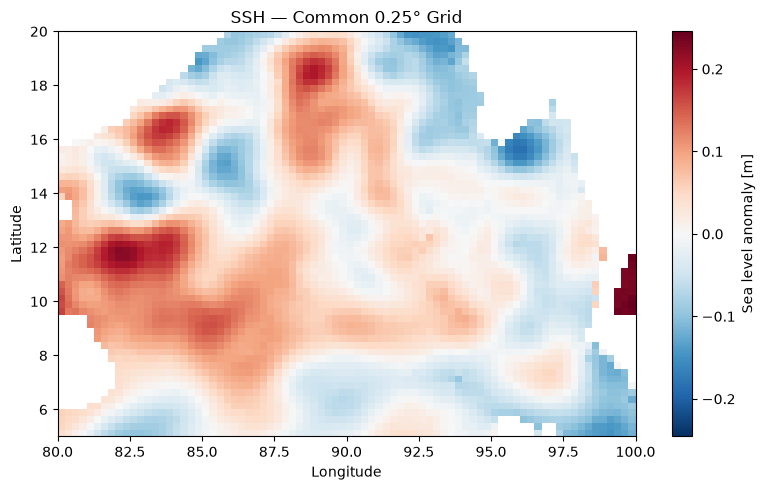

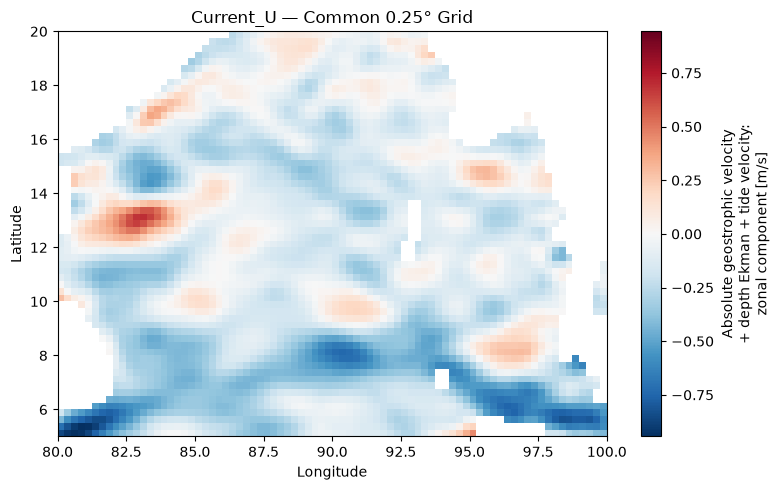

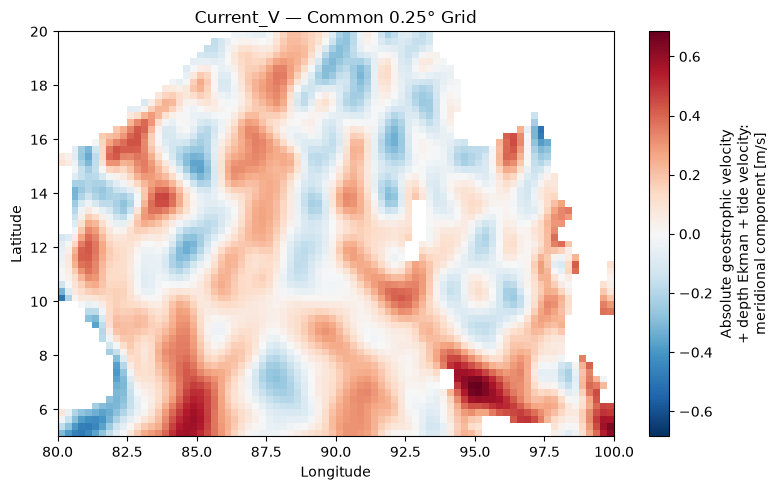

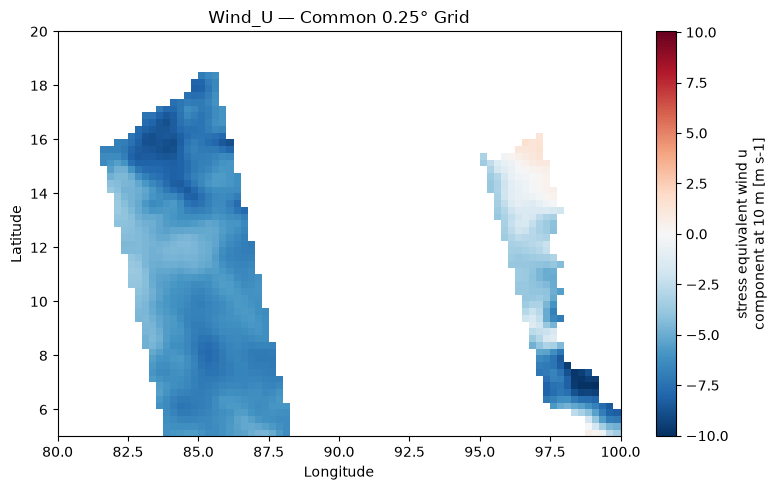

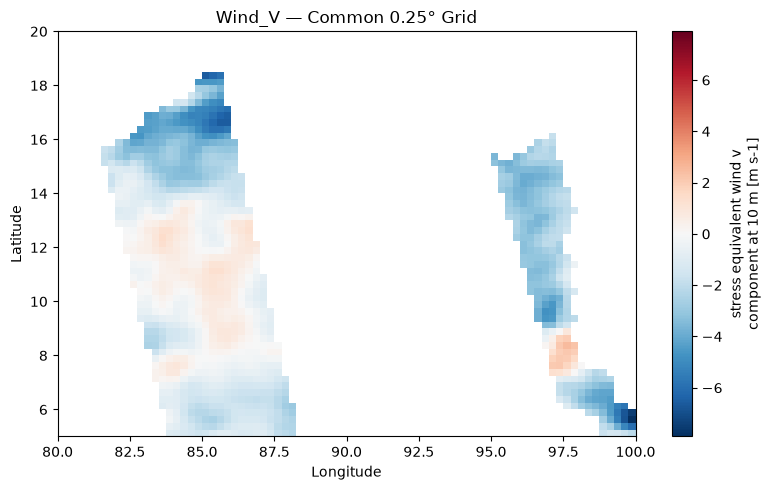

In [451]:
import matplotlib.pyplot as plt

variables = [
    "SST",
    "SSS",
    "SSH",
    "Current_U",
    "Current_V",
    "Wind_U",
    "Wind_V",
]

for var in variables:
    plt.figure(figsize=(8, 5))

    surface_common[var].isel(time=0).plot()

    plt.title(f"{var} — Common 0.25° Grid")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"{var.lower()}_common_grid_20200101.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

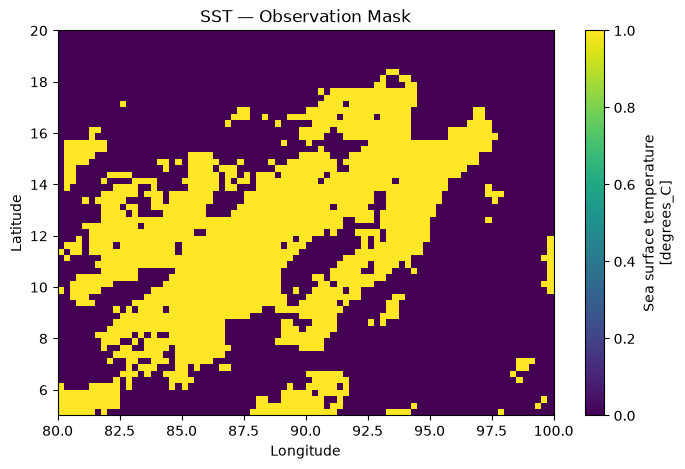

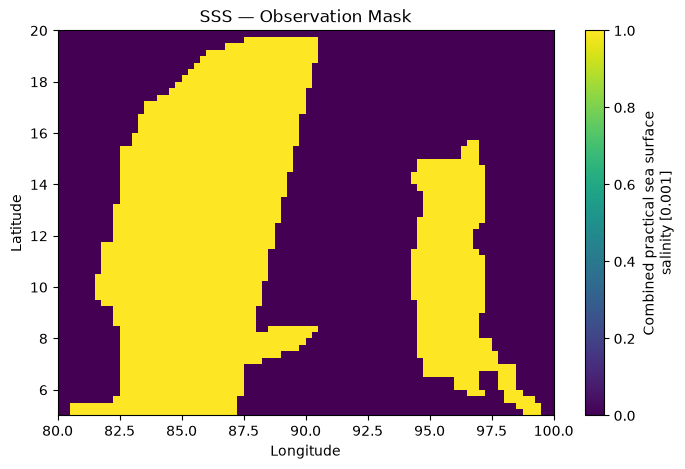

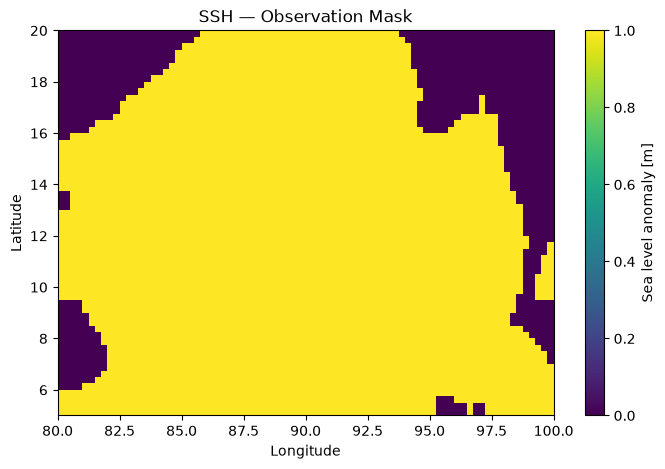

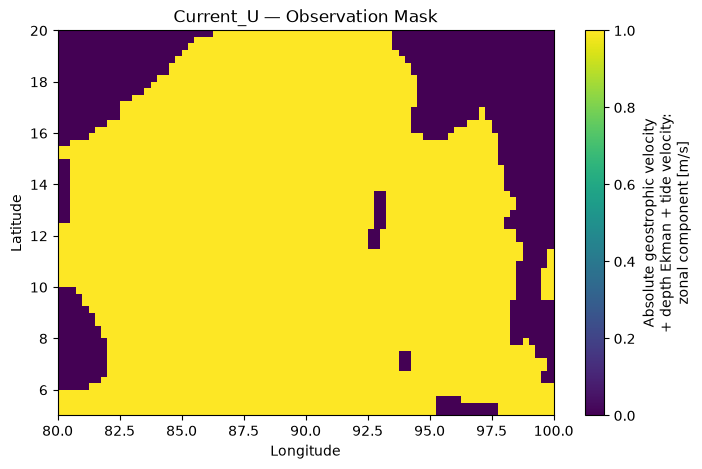

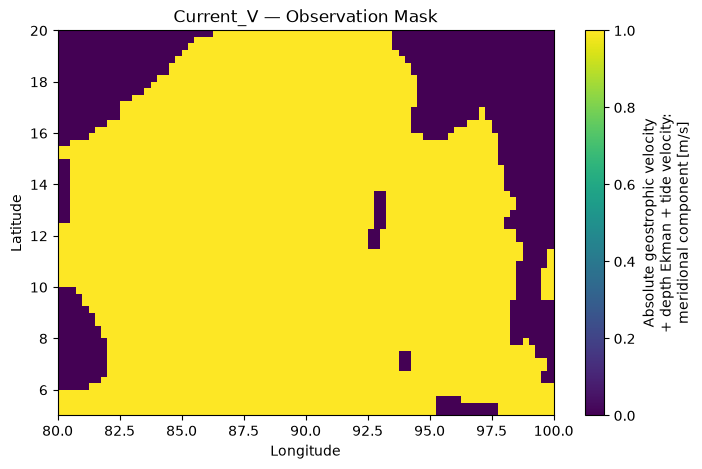

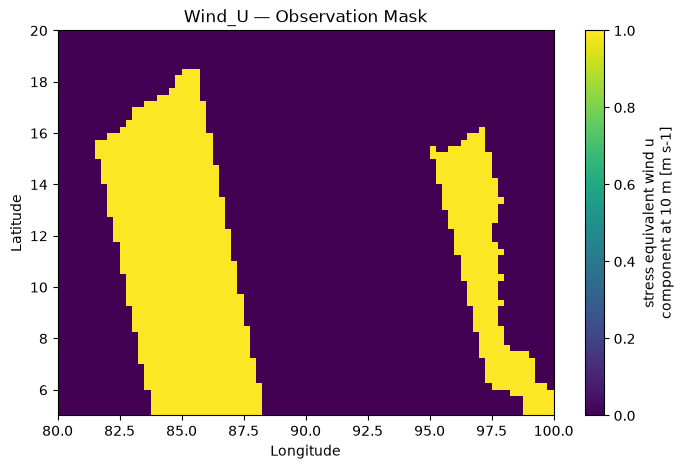

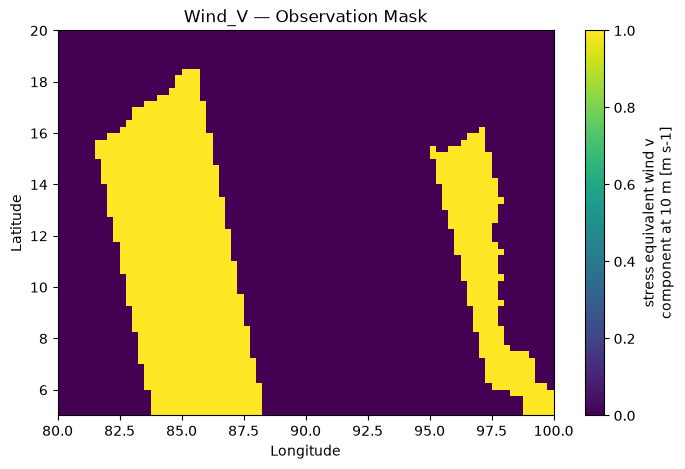

In [271]:
for var in variables:
    plt.figure(figsize=(8, 5))

    surface_common[var].isel(time=0).notnull().plot()

    plt.title(f"{var} — Observation Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

## Step 14 — Convert GLORYS to the 15 target depths

0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

In [272]:
# ============================================================
# Step 14 — GLORYS Vertical Interpolation
# ============================================================

target_depths = xr.DataArray(
    [0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
     200, 300, 500, 700, 1000],
    dims="depth",
    name="depth"
)

print(target_depths)

<xarray.DataArray 'depth' (depth: 15)> Size: 120B
array([   0,    5,   10,   20,   30,   50,   75,  100,  125,  150,  200,
        300,  500,  700, 1000])
Dimensions without coordinates: depth


14.2 Handle the 0-m target carefully

GLORYS starts at approximately:

0.494 m

not exactly 0 m.

We should not extrapolate from the 0.494-m level to 0 m.

For this prototype, use the shallowest GLORYS level as the 0-m proxy:

In [273]:
print("Original shallowest depth:",
      float(thetao_std.depth.values[0]))

print("Original deepest depth:",
      float(thetao_std.depth.values[-1])) #basically the shallowest one will be treated as 0m

Original shallowest depth: 0.49402499198913574
Original deepest depth: 1062.43994140625


In [452]:

thetao_for_interp = thetao_std.assign_coords(
    depth=xr.where(
        thetao_for_interp.depth == thetao_for_interp.depth[0],
        0,
        thetao_for_interp.depth
    )
)

In [454]:
print(
    "Interpolation depth range:",
    float(thetao_for_interp.depth.min().compute()),
    "→",
    float(thetao_for_interp.depth.max().compute())
)

print(
    "Target depth range:",
    float(target_depths.min()),
    "→",
    float(target_depths.max())
)

Interpolation depth range: 0.0 → 1062.43994140625
Target depth range: 0.0 → 1000.0


In [275]:
#vertical interpolation
thetao_15depth = thetao_for_interp.interp(
    depth=target_depths
)

In [277]:
print("Target depths:")
print(thetao_15depth.depth.values)

Target depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


In [278]:
thetao_mean_profile = thetao_15depth.mean(
    dim=["time", "latitude", "longitude"],
    skipna=True
)

print(thetao_mean_profile)

<xarray.DataArray 'thetao' (depth: 15)> Size: 120B
array([27.57763992, 27.5466555 , 27.55135249, 27.62748265, 27.64868865,
       27.03246566, 24.64631737, 21.39086278, 18.51036665, 16.34707553,
       13.86205734, 11.67115606,  9.99188359,  8.54337128,  6.67813078])
Coordinates:
  * depth    (depth) int64 120B 0 5 10 20 30 50 75 ... 150 200 300 500 700 1000
Attributes:
    cell_methods:   area: mean
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    unit_long:      Degrees Celsius
    units:          degrees_C
    valid_max:      21306
    valid_min:      -32766


In [457]:
missing_profile = (
    100 * thetao_15depth.isnull().mean(
        dim=["time", "latitude", "longitude"]
    )
).compute()

for depth in target_depths:
    missing_pct = missing_profile.sel(depth=depth).item()

    print(
        f"{depth:4.0f} m | "
        f"missing = {missing_pct:.2f}%"
    )

   0 m | missing = 18.85%
   5 m | missing = 18.85%
  10 m | missing = 20.58%
  20 m | missing = 22.27%
  30 m | missing = 23.87%
  50 m | missing = 26.09%
  75 m | missing = 28.02%
 100 m | missing = 29.85%
 125 m | missing = 30.36%
 150 m | missing = 30.75%
 200 m | missing = 31.44%
 300 m | missing = 32.32%
 500 m | missing = 34.08%
 700 m | missing = 35.40%
1000 m | missing = 37.39%


## Step 15 — Regrid GLORYS horizontally

GLORYS native
181 × 241
      ↓
vertical interpolation
15 depths
      ↓
horizontal interpolation
60 × 80
      ↓
Y
(time, depth, latitude, longitude)

In [280]:
thetao_common = thetao_15depth.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [281]:
print(thetao_common)

<xarray.DataArray 'thetao' (time: 31, depth: 15, latitude: 60, longitude: 80)> Size: 18MB
array([[[[28.36216315, 28.40519424, 28.42533646, ..., 29.40369884,
          29.72927029, 29.82613604],
         [28.25962095, 28.27793206, 28.32718893, ..., 29.39765617,
          29.57087923, 30.05758842],
         [28.54820398, 28.33341471, 28.27628406, ..., 29.21875667,
          29.49287392, 30.10318307],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[28.31588983, 28.35761639, 28.37866278, ..., 29.27018698,
          29.64148247, 29.68940275],
         [28.22297287, 28.24490067, 28.29559968, ..., 29.34211657,
          29.51804598, 29.96602458],
         [28.50884336, 28.30129888, 28.24471756, ..., 29.17849

In [282]:
print("Shape:", thetao_common.shape)
print("Depths:", thetao_common.depth.values)
print("Lat:", thetao_common.latitude.values[[0, -1]])
print("Lon:", thetao_common.longitude.values[[0, -1]])

Shape: (31, 15, 60, 80)
Depths: [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]
Lat: [ 5.125 19.875]
Lon: [80.125 99.875]


## Step 16 — Align everything and construct X/Y

X channels = 7
SST
SSS
SSH
Current_U
Current_V
Wind_U
Wind_V

Y depths = 15
0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

In [458]:
# ============================================================
# Step 16 — Align Surface Inputs and GLORYS Target
# ============================================================

surface_common, thetao_common = xr.align(
    surface_common,
    thetao_common,
    join="exact"
)

print("Surface dimensions:")
print(surface_common.sizes)

print("\nTarget dimensions:")
print(thetao_common.sizes)

assert surface_common.sizes["time"] == thetao_common.sizes["time"]
assert surface_common.sizes["latitude"] == thetao_common.sizes["latitude"]
assert surface_common.sizes["longitude"] == thetao_common.sizes["longitude"]

Surface dimensions:
Frozen({'time': 31, 'latitude': 60, 'longitude': 80})

Target dimensions:
Frozen({'time': 31, 'depth': 15, 'latitude': 60, 'longitude': 80})


In [284]:
input_variables = [
    "SST",
    "SSS",
    "SSH",
    "Current_U",
    "Current_V",
    "Wind_U",
    "Wind_V",
]

X_da = xr.concat(
    [surface_common[var] for var in input_variables],
    dim="channel"
)

X_da = X_da.assign_coords(
    channel=input_variables
)

X_da.name = "surface_inputs"

print(X_da)

<xarray.DataArray 'surface_inputs' (channel: 7, time: 31, latitude: 60,
                                    longitude: 80)> Size: 8MB
array([[[[ 2.85843764e+01,  2.85662515e+01,  2.86475002e+01, ...,
                      nan,             nan,             nan],
         [ 2.85975000e+01,  2.86312513e+01,  2.86637507e+01, ...,
           2.80287554e+01,             nan,             nan],
         [ 2.89249990e+01,  2.88399992e+01,  2.86618734e+01, ...,
                      nan,  2.87406229e+01,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                

In [285]:
Y_da = thetao_common.rename(
    "subsurface_temperature"
)

print(Y_da)

<xarray.DataArray 'subsurface_temperature' (time: 31, depth: 15, latitude: 60,
                                            longitude: 80)> Size: 18MB
array([[[[28.36216315, 28.40519424, 28.42533646, ..., 29.40369884,
          29.72927029, 29.82613604],
         [28.25962095, 28.27793206, 28.32718893, ..., 29.39765617,
          29.57087923, 30.05758842],
         [28.54820398, 28.33341471, 28.27628406, ..., 29.21875667,
          29.49287392, 30.10318307],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[28.31588983, 28.35761639, 28.37866278, ..., 29.27018698,
          29.64148247, 29.68940275],
         [28.22297287, 28.24490067, 28.29559968, ..., 29.34211657,
          29.51804598, 29.96602458],
  

In [286]:
X_mask = X_da.notnull()

X_mask.name = "surface_observation_mask"

print(X_mask)

<xarray.DataArray 'surface_observation_mask' (channel: 7, time: 31,
                                              latitude: 60, longitude: 80)> Size: 1MB
array([[[[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ..., False,  True, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[ True,  True,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False],
  

In [287]:
Y_mask = Y_da.notnull()

Y_mask.name = "target_valid_mask"

In [288]:
X_da = X_da.transpose(
    "time",
    "channel",
    "latitude",
    "longitude"
)

X_mask = X_mask.transpose(
    "time",
    "channel",
    "latitude",
    "longitude"
)

print("X shape:", X_da.shape)
print("Mask shape:", X_mask.shape)

X shape: (31, 7, 60, 80)
Mask shape: (31, 7, 60, 80)


In [289]:
print("========== FINAL PROTOTYPE SHAPES ==========")

print("X:", X_da.shape)
print("Y:", Y_da.shape)
print("X mask:", X_mask.shape)
print("Y mask:", Y_mask.shape)

print("\nChannels:")
print(X_da.channel.values)

print("\nTarget depths:")
print(Y_da.depth.values)

========== FINAL PROTOTYPE SHAPES ==========
X: (31, 7, 60, 80)
Y: (31, 15, 60, 80)
X mask: (31, 7, 60, 80)
Y mask: (31, 15, 60, 80)

Channels:
['SST' 'SSS' 'SSH' 'Current_U' 'Current_V' 'Wind_U' 'Wind_V']

Target depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


In [290]:
joint_input_mask = X_mask.all(dim="channel")

print(
    "Grid cells with all 7 inputs available:",
    int(joint_input_mask.sum())
)

print(
    "Total grid cells:",
    joint_input_mask.size
)

print(
    "Joint missing percentage:",
    100 * float((~joint_input_mask).mean())
)

Grid cells with all 7 inputs available: 8783
Total grid cells: 148800
Joint missing percentage: 94.09744623655914


Step 17 — Define the missing-input strategy

observed value → keep it
missing value  → replace with a neutral value
mask           → tell model whether it was observed


raw X
 ↓
QC
 ↓
common grid
 ↓
split train/validation/test
 ↓
calculate training statistics
 ↓
normalize
 ↓
fill missing normalized values with 0
 ↓
provide observation mask separately

# Step 17 — Missing-Input Strategy

The surface observations have substantially different spatial coverage.
On the one-day prototype, only approximately 10.08% of grid cells contain
simultaneous observations from all seven surface variables.

Discarding all grid cells with any missing input would therefore remove most
of the available spatial domain.

ANTARBODH therefore preserves missing observations using an explicit
observation-mask representation.

For each surface variable:

- observed values are retained;
- missing values remain NaN during the preprocessing stage;
- a binary observation mask is retained;
- missing values will later be replaced by zero only after training-set
  normalization;
- the corresponding mask will be supplied to the model so that zero-imputed
  values are distinguishable from genuine zero-valued observations.

This allows the model to use partially observed surface fields without
treating missing observations as physical measurements.

No target temperature values are imputed at this stage.

In [291]:
print(X_mask)

<xarray.DataArray 'surface_observation_mask' (time: 31, channel: 7,
                                              latitude: 60, longitude: 80)> Size: 1MB
array([[[[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ..., False,  True, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False,  True, ...,  True, False, False],
         [False, False,  True, ...,  True, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
  

In [459]:
channel_coverage = (
    100 * X_mask.mean(dim=["time", "latitude", "longitude"])
).compute()

print("========== INPUT COVERAGE ==========")

for channel in X_mask.channel.values:
    coverage = channel_coverage.sel(channel=channel).item()

    print(
        f"{channel:12s} | "
        f"coverage = {coverage:.2f}%"
    )

========== INPUT COVERAGE ==========
SST          | coverage = 54.75%
SSS          | coverage = 22.60%
SSH          | coverage = 82.17%
Current_U    | coverage = 78.81%
Current_V    | coverage = 78.81%
Wind_U       | coverage = 24.94%
Wind_V       | coverage = 24.94%


split time before normalization

This is where we need to start thinking about your eventual 5-year dataset.

Never calculate normalization statistics using the entire 5-year dataset before splitting.

That would leak information from validation/test periods into training.

Eventually:
```mermaid
2020–2023 → training
2024      → validation
2025      → test
```
or another chronological split you choose.

Then:
```mermaid
training data
      ↓
mean/std
      ↓
normalize train
normalize validation
normalize test
```


Validation and test use training statistics only.

For the current one-day prototype, we can't meaningfully create a realistic multi-year temporal split because we have only one day.

So don't calculate the final normalization statistics yet.

In [460]:
target_coverage = (
    100 * Y_mask.mean(
        dim=["time", "latitude", "longitude"]
    )
).compute()

print("========== TARGET COVERAGE ==========")

for depth in Y_da.depth.values:
    coverage = target_coverage.sel(depth=depth).item()

    print(
        f"{depth:4.0f} m | "
        f"coverage = {coverage:.2f}%"
    )

========== TARGET COVERAGE ==========
   0 m | coverage = 80.17%
   5 m | coverage = 80.17%
  10 m | coverage = 78.40%
  20 m | coverage = 76.65%
  30 m | coverage = 75.06%
  50 m | coverage = 72.88%
  75 m | coverage = 70.77%
 100 m | coverage = 69.15%
 125 m | coverage = 68.71%
 150 m | coverage = 68.38%
 200 m | coverage = 67.52%
 300 m | coverage = 66.81%
 500 m | coverage = 65.02%
 700 m | coverage = 63.42%
1000 m | coverage = 61.29%


In [462]:
print(
    "Any valid target:",
    bool(Y_mask.any().compute())
)

Any valid target: True


## Step 29 — Finalize the prototype dataset

Before normalization, let's establish one important principle:

We do not need every target depth to be valid at every grid cell.

The target mask Y_mask will tell us which target values are available.

For training, later, the loss can be computed only over valid target locations.

So we preserve:

Y
+
Y_mask

rather than filling missing GLORYS temperatures.

In [467]:
# ============================================================
# Step 29 — Create ML-ready Prototype Dataset
# ============================================================

processed = xr.Dataset(
    {
        "X": X_da,
        "X_mask": X_mask.astype(np.int8),
        "Y": Y_da,
        "Y_mask": Y_mask.astype(np.int8),
    }
)

processed.attrs["project"] = "ANTARBODH"
processed.attrs["description"] = (
    "ANTARBODH model-ready surface observations and "
    "GLORYS-derived subsurface temperature targets"
)

processed.attrs["time_start"] = str(
    processed.time.values[0]
)

processed.attrs["time_end"] = str(
    processed.time.values[-1]
)
processed.attrs["region"] = "Bay of Bengal prototype"
processed.attrs["grid_resolution"] = "0.25 degree"
processed.attrs["input_channels"] = 7
processed.attrs["target_depths"] = (
    "0, 5, 10, 20, 30, 50, 75, 100, 125, "
    "150, 200, 300, 500, 700, 1000 m"
)

print(processed)

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 31, latitude: 60, longitude: 80, channel: 7, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
  * channel    (channel) <U9 252B 'SST' 'SSS' 'SSH' ... 'Wind_U' 'Wind_V'
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
Data variables:
    X          (time, channel, latitude, longitude) float64 8MB 28.58 ... nan
    X_mask     (time, channel, latitude, longitude) int8 1MB 1 1 1 1 ... 0 0 0 0
    Y          (time, depth, latitude, longitude) float64 18MB 28.36 ... nan
    Y_mask     (time, depth, latitude, longitude) int8 2MB 1 1 1 1 1 ... 0 0 0 0
Attributes:
    project:          ANTARBODH
    description:      ANTARBODH model-ready surface observations and GLORYS-d...
    time_start:       2020-01-01

In [297]:
print("========== FINAL DIMENSION CHECK ==========")

print("X:")
print(processed["X"].dims, processed["X"].shape)

print("\nX mask:")
print(processed["X_mask"].dims, processed["X_mask"].shape)

print("\nY:")
print(processed["Y"].dims, processed["Y"].shape)

print("\nY mask:")
print(processed["Y_mask"].dims, processed["Y_mask"].shape)

========== FINAL DIMENSION CHECK ==========
X:
('time', 'channel', 'latitude', 'longitude') (31, 7, 60, 80)

X mask:
('time', 'channel', 'latitude', 'longitude') (31, 7, 60, 80)

Y:
('time', 'depth', 'latitude', 'longitude') (31, 15, 60, 80)

Y mask:
('time', 'depth', 'latitude', 'longitude') (31, 15, 60, 80)


In [298]:
print("X NaNs:", int(processed["X"].isnull().sum()))
print("Y NaNs:", int(processed["Y"].isnull().sum()))

X NaNs: 495465
Y NaNs: 648210


In [464]:
for name in ["X", "Y"]:
    has_inf = bool(
        np.isinf(processed[name]).any().compute()
    )

    print(name, "has Inf:", has_inf)

X has Inf: False
Y has Inf: False


In [465]:
x_mask_correct = bool(
    (
        X_da.notnull()
        == processed["X_mask"].astype(bool)
    ).all().compute()
)

print("X mask correct:", x_mask_correct)

X mask correct: True


In [466]:

y_mask_correct = bool(
    (
        Y_da.notnull()
        == processed["Y_mask"].astype(bool)
    ).all().compute()
)

print("Y mask correct:", y_mask_correct)

Y mask correct: True


In [302]:
print("Latitude:")
print(processed.latitude.values[[0, -1]])

print("\nLongitude:")
print(processed.longitude.values[[0, -1]])

print("\nDepth:")
print(processed.depth.values)

print("\nChannels:")
print(processed.channel.values)

Latitude:
[ 5.125 19.875]

Longitude:
[80.125 99.875]

Depth:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]

Channels:
['SST' 'SSS' 'SSH' 'Current_U' 'Current_V' 'Wind_U' 'Wind_V']


In [468]:
print("X time:")
print(X_da.time)

print("\nY time:")
print(Y_da.time)

print("\nNumber of X timesteps:", X_da.sizes["time"])
print("Number of Y timesteps:", Y_da.sizes["time"])

assert X_da.sizes["time"] == Y_da.sizes["time"]
assert X_da.time.equals(Y_da.time)

print("✓ X and Y time coordinates match")

X time:
<xarray.DataArray 'time' (time: 31)> Size: 248B
array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000',
       '2020-01-11T00:00:00.000000000', '2020-01-12T00:00:00.000000000',
       '2020-01-13T00:00:00.000000000', '2020-01-14T00:00:00.000000000',
       '2020-01-15T00:00:00.000000000', '2020-01-16T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-19T00:00:00.000000000', '2020-01-20T00:00:00.000000000',
       '2020-01-21T00:00:00.000000000', '2020-01-22T00:00:00.000000000',
       '2020-01-23T00:00:00.000000000', '2020-01-24T00:00:00.000000000',
       '2020-01-25T00:00:00.000000000', '2020-01-26T00:00:00.0000000

In [469]:
time_values = X_da.time.values

print(
    "Duplicate timestamps:",
    len(time_values) - len(np.unique(time_values))
)

Duplicate timestamps: 0


In [471]:
time_diff = X_da.time.diff("time")

print("Time differences:")
print(time_diff.to_pandas().value_counts())

Time differences:
time
1 days    30
Name: count, dtype: int64


In [473]:
all_inputs_available = X_mask.all(dim="channel")

daily_input_coverage = (
    100 * all_inputs_available.mean(
        dim=["latitude", "longitude"]
    )
).compute()
daily_input_coverage

<xarray.DataArray 'surface_observation_mask' (time: 31)> Size: 248B
array([10.08333333,  2.875     ,  6.33333333, 14.95833333,  2.9375    ,
       17.6875    ,  7.10416667,  0.02083333,  7.25      ,  0.16666667,
       10.66666667,  8.58333333,  0.72916667,  8.89583333,  7.70833333,
        3.58333333, 11.97916667,  3.33333333,  4.91666667,  5.45833333,
        1.16666667,  7.4375    ,  0.91666667,  3.0625    ,  2.1875    ,
       18.47916667,  4.85416667,  0.        ,  4.5625    ,  0.5625    ,
        4.47916667])
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Attributes:
    authority:      CF-1.7
    long_name:      Sea surface temperature
    standard_name:  sea_surface_foundation_temperature
    type:           foundation
    units:          degrees_C
    valid_max:      4500
    valid_min:      -300

In [475]:
daily_target_coverage = (
    100 * Y_mask.mean(
        dim=["depth", "latitude", "longitude"]
    )
).compute()
daily_target_coverage

<xarray.DataArray 'target_valid_mask' (time: 31)> Size: 248B
array([70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333, 70.95833333, 70.95833333, 70.95833333, 70.95833333,
       70.95833333])
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Attributes:
    cell_methods:   area: mean
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    unit_long:      Degrees Celsius
    units:          degrees_C
    valid_max:      21306
    valid_min:      -32766

In [476]:
joint_target_input = (
    X_mask.any(dim="channel") &
    Y_mask.any(dim="depth")
)

overall_joint_fraction = (
    joint_target_input.mean().compute().item()
)

print(
    "Overall input-target spatial coverage:",
    overall_joint_fraction * 100,
    "%"
)

Overall input-target spatial coverage: 79.89045698924731 %


## Step 30 — Chronological split
```mermaid
TRAIN       VALIDATION       TEST

2020 ───────── 2023 | 2024 | 2025
       4 years       | 1 yr | 1 yr
```


In [ ]:
train_mask = X_da.time.dt.year <= 2023
val_mask = X_da.time.dt.year == 2024
test_mask = X_da.time.dt.year == 2025

In [ ]:
X_train = X_da.sel(time=train_mask)
X_val = X_da.sel(time=val_mask)
X_test = X_da.sel(time=test_mask)

Y_train = Y_da.sel(time=train_mask)
Y_val = Y_da.sel(time=val_mask)
Y_test = Y_da.sel(time=test_mask)

Xmask_train = X_mask.sel(time=train_mask)
Xmask_val = X_mask.sel(time=val_mask)
Xmask_test = X_mask.sel(time=test_mask)

Ymask_train = Y_mask.sel(time=train_mask)
Ymask_val = Y_mask.sel(time=val_mask)
Ymask_test = Y_mask.sel(time=test_mask)

In [ ]:
print("Train:", X_train.time.values[0], "→", X_train.time.values[-1])
print("Val:  ", X_val.time.values[0], "→", X_val.time.values[-1])
print("Test: ", X_test.time.values[0], "→", X_test.time.values[-1])

## step 31-Calculate normalization statistics from TRAIN ONLY


In [ ]:
train_mean = X_train.mean(
    dim=["time", "latitude", "longitude"],
    skipna=True
)

train_std = X_train.std(
    dim=["time", "latitude", "longitude"],
    skipna=True
)

In [ ]:
train_mean = train_mean.compute()
train_std = train_std.compute()

## step 32-Normalize X

In [ ]:
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

## step 33-Handle missing input values

In [ ]:
X_train_norm = X_train_norm.fillna(0)
X_val_norm = X_val_norm.fillna(0)
X_test_norm = X_test_norm.fillna(0)

## step 34-Create the 14-channel model input

In [ ]:
def make_14_channel_input(X_norm, Xmask):
    mask_channels = Xmask.astype(np.float32)

    mask_channels = mask_channels.assign_coords(
        channel=[
            f"{c}_mask"
            for c in X_norm.channel.values
        ]
    )

    return xr.concat(
        [X_norm, mask_channels],
        dim="channel"
    )

In [ ]:
X_train_14 = make_14_channel_input(
    X_train_norm,
    Xmask_train
)

X_val_14 = make_14_channel_input(
    X_val_norm,
    Xmask_val
)

X_test_14 = make_14_channel_input(
    X_test_norm,
    Xmask_test
)

## step 35-Final dataset objects

In [ ]:
train_ds = xr.Dataset({
    "X": X_train_14,
    "Y": Y_train,
    "Y_mask": Ymask_train.astype(np.int8),
})

val_ds = xr.Dataset({
    "X": X_val_14,
    "Y": Y_val,
    "Y_mask": Ymask_val.astype(np.int8),
})

test_ds = xr.Dataset({
    "X": X_test_14,
    "Y": Y_test,
    "Y_mask": Ymask_test.astype(np.int8),
})

In [ ]:
print("========== FINAL ML SHAPES ==========")

print("Train X:", train_ds["X"].shape)
print("Train Y:", train_ds["Y"].shape)

print("Val X:", val_ds["X"].shape)
print("Val Y:", val_ds["Y"].shape)

print("Test X:", test_ds["X"].shape)
print("Test Y:", test_ds["Y"].shape)

In [ ]:
print(train_ds.X.channel.values)
print(train_ds.Y.depth.values)
assert train_ds.X.dims == (
    "time", "channel", "latitude", "longitude"
)

assert train_ds.Y.dims == (
    "time", "depth", "latitude", "longitude"
)

In [ ]:
train_norm_mean = X_train_norm.mean(
    dim=["time", "latitude", "longitude"],
    skipna=False
).compute()

train_norm_std = X_train_norm.std(
    dim=["time", "latitude", "longitude"],
    skipna=False
).compute()

print("Training normalized mean:")
print(train_norm_mean)

print("\nTraining normalized std:")
print(train_norm_std)

## step 36-Save only after everything passes